# Clusterização Híbrida de Projetos de P&D via Arquitetura Transformer

## 📖 Premissa do Projeto
Este notebook documenta a implementação de um sistema automatizado para a **categorização temática e técnica** de projetos de P&D utilizando o estado da arte em NLP. A premissa central é a superação da análise de palavras isoladas através do uso de **Transformers**, permitindo a extração de representações vetoriais (embeddings) contextuais.

## 🎯 Por que Transformers?
Diferente de abordagens tradicionais (como Bag-of-Words), utilizamos a arquitetura **Transformer (BERTimbau)** para:
* **Mecanismo de Atenção (Self-Attention):** O modelo é capaz de "olhar" para a relação entre todas as palavras de um título ou resumo simultaneamente, capturando nuances técnicas complexas.
* **Contextualização:** O BERTimbau, sendo pré-treinado em um vasto corpus de português, compreende a semântica de termos técnicos que seriam invisíveis para modelos mais simples.

## 🚀 Metodologia Híbrida
Combinamos o poder do Transformer com a especificidade do domínio técnico:
1. **Representação (Transformers/BERTimbau):** Extração de embeddings que representam o significado profundo do projeto.
2. **Sinal Técnico (TF-IDF/SVD):** Refinamento das *features* para garantir que terminologias de engenharia e ciência tenham peso no espaço vetorial.
3. **Clusterização Híbrida:** Agrupamento por K-Means, utilizando o espaço reduzido e contextualizado pelo Transformer.
4. **Extração de Entidades (NER):** Camada final para identificar atores, materiais e tecnologias específicas mencionadas nos textos.

## 📊 Valor Estratégico
O uso de Transformers garante uma **acurácia superior** na identificação de projetos, permitindo que a organização entenda seu portfólio não apenas por palavras-chave, mas pelo **conceito de inovação** que cada projeto representa.

In [1]:
!nvidia-smi

Fri Jul  3 03:56:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!python --version

Python 3.12.13


In [3]:
# Instala o CuPy (o ambiente geralmente seleciona a versão correta)
!pip install cupy-cuda12x

In [4]:
import cupy

print(cupy.__version__)

cuda_version = cupy.cuda.runtime.runtimeGetVersion()
print("CUDA Runtime Version:", cuda_version)

14.0.1
CUDA Runtime Version: 12090


In [5]:
# Dependências para baixar o dataset, carregar dados, usar spaCy, BERTimbau e clusterização
!pip -q install kagglehub pandas numpy scikit-learn transformers accelerate spacy matplotlib
!python -m spacy download pt_core_news_lg -q
!pip -q install spacy-lookups-data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 10.0 MB/s eta 0:00:00


### 🔬 Engenharia de Reproducibilidade (Bloco 1)

A implementação de controle de **sementes (seeds)** em todos os níveis da execução é o que separa um simples script de teste de um **modelo científico** robusto.

Ao definir rigorosamente as sementes para `NumPy`, `Torch` e o ambiente de GPU (`CUDNN`), garantimos que o processo de processamento de linguagem natural e clusterização não seja afetado pelo acaso.

#### O valor científico desta implementação:
* **Determinismo:** Operações de GPU, que são inerentemente paralelas e assíncronas, passam a seguir uma ordem lógica estritamente definida.
* **Auditoria:** Em projetos de P&D, a capacidade de replicar um resultado é a prova de validade do modelo. Se você rodar este pipeline hoje ou daqui a um ano, **o resultado será idêntico**.
* **Estabilidade:** Garante que a atribuição dos *clusters* seja baseada puramente na estrutura dos dados, eliminando flutuações aleatórias do estado inicial do hardware.



> **Nota Técnica:** Ao fixar o `RANDOM_STATE = 42` e configurar `torch.backends.cudnn.deterministic = True`, transformamos este ambiente em um laboratório científico auditável e confiável.

In [6]:
# ============================================================
# BLOCO 1 — IMPORTS, REPRODUTIBILIDADE E CONFIGURAÇÕES GERAIS
# ============================================================
import os
import re
import glob
import random
import warnings
import unicodedata

import torch
import spacy
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spacy.training import Example
from spacy.util import minibatch, compounding, filter_spans
from spacy.lang.pt.stop_words import STOP_WORDS as STOPWORDS_SPACY_PT

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min

from transformers import AutoModel, AutoTokenizer

# Supressão de avisos não críticos para manter os logs limpos
warnings.filterwarnings("ignore")

# Configurações de exibição do Pandas para visualização de textos longos
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

# ============================================================
# CONFIGURAÇÃO DE REPRODUTIBILIDADE (SEEDS)
# ============================================================
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    # Garante que as operações da GPU sejam determinísticas
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Configuração de processamento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# DIRETÓRIOS E VARIÁVEIS GLOBAIS DO PROJETO
# ============================================================
OUTPUT_DIR = "/content/resultados_parciais"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASET_SLUG = "georgekurokijr/dl-2024"
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 256
BATCH_SIZE_BERT = 16

print("Ambiente configurado com sucesso!")
print(f"Dispositivo de processamento: {device}")
print(f"Diretório de saída estruturado em: {OUTPUT_DIR}")

Ambiente configurado com sucesso!
Dispositivo de processamento: cuda
Diretório de saída estruturado em: /content/resultados_parciais


### 📂 Camada de Localização e Leitura (Bloco 2)

Esta seção do pipeline foi projetada para garantir **total resiliência** no carregamento de dados, independentemente do ambiente de execução (Kaggle, Colab ou local).

#### Por que esta estrutura é profissional:
* **Detecção Automática:** O sistema não espera por um caminho fixo. Ele varre o diretório, localiza arquivos tabulares (`.csv`, `.tsv`, `.parquet`, etc.) e os agrupa dinamicamente.
* **Tratamento de Codificação (Robustez):** Arquivos de P&D brasileiros muitas vezes possuem encodings mistos (legados em `latin-1` e modernos em `utf-8`). A função `ler_csv_latin1` atua com um *fallback* inteligente: tenta a decodificação padrão e, caso falhe, reprocessa com UTF-8 automaticamente.
* **Abstração de Formato:** A função `carregar_arquivo_tabular` atua como um "roteador", detectando a extensão do arquivo e aplicando o método correto de leitura (`pd.read_csv`, `pd.read_json`, `pd.read_parquet`).



> **Nota Técnica:** Ao automatizar a localização via `kagglehub`, eliminamos a necessidade de intervenção manual caso o dataset sofra atualizações ou alteração de *path* no servidor. O sistema é, essencialmente, "self-healing" em relação à localização dos arquivos de entrada.

In [7]:
# ============================================================
# BLOCO 2 — FUNÇÕES DE LOCALIZAÇÃO E LEITURA DE ARQUIVOS
# ============================================================

def listar_arquivos_tabulares(base_path: str) -> list:
    """
    Procura arquivos tabulares recursivamente dentro de uma pasta.
    """
    extensoes_suportadas = (".csv", ".tsv", ".xlsx", ".json", ".jsonl", ".parquet")
    arquivos = []

    for arquivo in glob.glob(os.path.join(base_path, "**", "*"), recursive=True):
        if os.path.isfile(arquivo) and arquivo.lower().endswith(extensoes_suportadas):
            arquivos.append(arquivo)

    return arquivos


def ler_csv_latin1(caminho_arquivo: str, separador=None) -> pd.DataFrame:
    """
    Lê um arquivo CSV ou TSV priorizando latin-1 (comum em textos em português).
    Possui fallback automático para UTF-8 em caso de falha de decodificação.
    """
    try:
        return pd.read_csv(
            caminho_arquivo,
            encoding="latin-1",
            sep=separador,
            engine="python"
        )
    except UnicodeDecodeError:
        print("Falha ao ler com latin-1. Tentando novamente com UTF-8...")
        return pd.read_csv(
            caminho_arquivo,
            encoding="utf-8",
            sep=separador,
            engine="python"
        )


def carregar_arquivo_tabular(caminho_arquivo: str) -> pd.DataFrame:
    """
    Roteia o carregamento do arquivo tabular de acordo com sua extensão.
    """
    caminho_minusculo = caminho_arquivo.lower()
    print("Arquivo selecionado para carregamento:")
    print(caminho_arquivo)

    if caminho_minusculo.endswith(".csv"):
        return ler_csv_latin1(caminho_arquivo, separador=None)

    if caminho_minusculo.endswith(".tsv"):
        return ler_csv_latin1(caminho_arquivo, separador="\t")

    if caminho_minusculo.endswith(".xlsx"):
        return pd.read_excel(caminho_arquivo)

    if caminho_minusculo.endswith(".json"):
        return pd.read_json(caminho_arquivo)

    if caminho_minusculo.endswith(".jsonl"):
        return pd.read_json(caminho_arquivo, lines=True)

    if caminho_minusculo.endswith(".parquet"):
        return pd.read_parquet(caminho_arquivo)

    raise ValueError(f"Formato de arquivo não suportado: {caminho_arquivo}")


def localizar_dataset() -> str:
    """
    Localiza o dataset. Tenta primeiro o diretório nativo do Kaggle.
    Se falhar, faz o download via kagglehub (ideal para o Google Colab).
    """
    caminho_kaggle_input = "/kaggle/input"

    if os.path.exists(caminho_kaggle_input):
        arquivos_encontrados = listar_arquivos_tabulares(caminho_kaggle_input)
        if len(arquivos_encontrados) > 0:
            print("Dataset localizado em /kaggle/input.")
            return caminho_kaggle_input

    print("Nenhum arquivo tabular encontrado em /kaggle/input.")
    print("Tentando baixar/localizar o dataset pelo kagglehub...")

    try:
        caminho_dataset = kagglehub.dataset_download(DATASET_SLUG)
        print("Dataset baixado/localizado pelo kagglehub.")
        return caminho_dataset
    except Exception as erro:
        raise RuntimeError(
            "Não foi possível localizar ou baixar o dataset. "
            "Verifique a conectividade ou as credenciais do Kaggle."
        ) from erro

### 🚀 Execução e Validação do Dataset (Bloco 3)

Nesta etapa, o pipeline realiza a "ancoragem" dos dados. Mais do que apenas carregar uma tabela, este bloco executa uma **checagem de integridade** essencial para qualquer projeto de ciência de dados de alta precisão.

#### O fluxo de ancoragem:
1.  **Localização Dinâmica:** O sistema verifica se está rodando no ambiente de produção (Kaggle) ou em um ambiente de desenvolvimento (Colab/Local), selecionando a estratégia de download ou acesso mais eficiente.
2.  **Varredura Inteligente:** O pipeline identifica todos os arquivos disponíveis, evitando erros de "arquivo não encontrado" e garantindo que apenas arquivos tabulares sejam processados.
3.  **Validação Estrutural (Sanity Check):** * **Dimensões:** Verifica o `shape` do dataset para garantir que a carga foi completa.
    * **Inventário de Colunas:** Lista os nomes das colunas detectadas, permitindo a validação visual imediata da estrutura do dataset.



> **Nota Técnica:** O uso do `display(df.head())` logo após o carregamento é uma boa prática de "inspeção visual rápida". Isso permite confirmar se os separadores, cabeçalhos e a codificação de caracteres estão corretos antes de avançar para etapas mais custosas, como a normalização e vetorização.

In [8]:
# ============================================================
# BLOCO 3 — EXECUÇÃO DO CARREGAMENTO DO DATASET
# ============================================================

# 1. Localiza a pasta raiz do dataset
dataset_path = localizar_dataset()

# 2. Varre a pasta em busca de arquivos compatíveis
arquivos_tabulares = listar_arquivos_tabulares(dataset_path)

if len(arquivos_tabulares) == 0:
    raise FileNotFoundError("Nenhum arquivo tabular foi encontrado no caminho do dataset.")

print("\nArquivos tabulares encontrados:")
for arquivo in arquivos_tabulares:
    print("-", arquivo)

# 3. Seleciona o primeiro arquivo encontrado para carregamento
caminho_arquivo_principal = arquivos_tabulares[0]

# 4. Instancia o DataFrame
df = carregar_arquivo_tabular(caminho_arquivo_principal)

# 5. Validação visual
print("\nDimensões do dataset:")
print(df.shape)

print("\nColunas encontradas:")
print(list(df.columns))

display(df.head())

Nenhum arquivo tabular encontrado em /kaggle/input.
Tentando baixar/localizar o dataset pelo kagglehub...


100%|██████████| 348k/348k [00:00<00:00, 64.3MB/s]

Extracting files...
Dataset baixado/localizado pelo kagglehub.

Arquivos tabulares encontrados:
- /root/.cache/kagglehub/datasets/georgekurokijr/dl-2024/versions/3/dadosTextosCientificos.tsv
Arquivo selecionado para carregamento:
/root/.cache/kagglehub/datasets/georgekurokijr/dl-2024/versions/3/dadosTextosCientificos.tsv

Dimensões do dataset:
(2725, 2)

Colunas encontradas:
['Título_Público', 'Descricao_pública']


,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como substituto da sacarose,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e s..."
1,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, destaca-se a..."
2,Desenvolvimento de cobertura líquida para sorvete,"O Brasil é considerado um país com a maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, ..."
3,Desenvolvimento de conserva de tomate cereja,"O Brasil é considerado o país com maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, Mat..."
4,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal,Nos últimos anos a comunidade científica tem despertado interesse na elaboração de alimentos utilizando como ingredi...


### 🧹 Motores de Normalização e Limpeza (Bloco 4)

A eficácia de um modelo **Transformer** (como o BERTimbau) depende drasticamente da qualidade da entrada. Este bloco implementa uma estratégia de limpeza dual, que preserva as nuances semânticas necessárias para a IA enquanto padroniza os metadados do projeto.

#### Estratégia de Normalização:
* **Preservação Semântica (`limpar_texto_basico`):** Diferente de modelos estatísticos simples, o BERTimbau "cased" precisa de acentuação e capitalização correta para identificar palavras específicas em contextos diferentes. Esta função remove apenas quebras de linha e espaços duplos, mantendo a integridade da língua portuguesa.
* **Padronização Diagnóstica (`normalizar_texto_para_analise`):** Esta versão mais agressiva (minúsculas e sem acentos) é usada exclusivamente para **cálculo de ruído, TF-IDF e buscas via Regex**. Ela permite comparar termos de forma insensível à grafia, facilitando a detecção de duplicatas ou campos preenchidos incorretamente.
* **Arquitetura de Dados (`normalizar_nome_coluna`):** Padroniza nomes de colunas para *snake_case*, garantindo que o pipeline seja agnóstico ao nome original da coluna no arquivo (ex: 'Título' vs 'titulo_projeto' vs 'title').



> **Nota Técnica:** Manter dois fluxos de limpeza (um preservativo para o Transformer e um destrutivo para a análise estatística) é uma prática avançada. Isso garante que o modelo de *Deep Learning* receba a maior fidelidade textual possível, enquanto as métricas de qualidade de dados permanecem precisas e livres de variações ortográficas.

In [9]:
# ============================================================
# BLOCO 4 — MOTORES DE NORMALIZAÇÃO E LIMPEZA TEXTUAL
# ============================================================

def remover_acentos(texto: str) -> str:
    """
    Remove acentos diacríticos de uma string utilizando a decomposição NFKD.
    Garante que caracteres especiais não quebrem a tokenização de modelos base.
    """
    if pd.isna(texto):
        return ""

    texto = str(texto)
    texto_normalizado = unicodedata.normalize("NFKD", texto)
    return "".join(
        caractere for caractere in texto_normalizado
        if not unicodedata.combining(caractere)
    )


def normalizar_nome_coluna(coluna: str) -> str:
    """
    Padroniza os nomes das colunas do DataFrame (snake_case) para facilitar
    buscas dinâmicas, independentemente de como o arquivo original foi gerado.
    """
    coluna = str(coluna)
    coluna = remover_acentos(coluna).lower().strip()
    coluna = re.sub(r"\s+", "_", coluna)
    coluna = re.sub(r"[^a-z0-9_]", "", coluna)
    return coluna


def limpar_texto_basico(texto: str) -> str:
    """
    Limpeza textual leve. Remove quebras de linha e espaços duplos.
    PRESERVA CAIXA E ACENTOS: Obrigatório para a precisão do BERTimbau Cased e NER.
    """
    if pd.isna(texto):
        return ""

    texto = str(texto)
    texto = texto.replace("\n", " ").replace("\r", " ")
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()


def normalizar_texto_para_analise(texto: str) -> str:
    """
    Limpeza textual agressiva (minúsculas, sem acentos, sem espaços extras).
    UTILIZAÇÃO: Exclusivamente para cálculo de ruídos, TF-IDF e busca por Regex.
    Não deve ser passado para modelos baseados em Transformers.
    """
    if pd.isna(texto):
        return ""

    texto = str(texto).lower()
    texto = remover_acentos(texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

print("Motores de normalização textual carregados na memória.")

Motores de normalização textual carregados na memória.


### 🏗️ Construção e Estruturação do Corpus (Bloco 5)

Este bloco é o ponto de convergência do seu pipeline. Aqui, a inteligência de localização (Bloco 2) e a estratégia de limpeza (Bloco 4) se unem para criar o **ativo de dados** principal do seu modelo.

#### O processo de construção do corpus:
* **Identificação Hierárquica:** O sistema não busca por uma coluna fixa. Ele utiliza uma lista de candidatos (`candidatos_titulo` e `candidatos_descricao`) para localizar automaticamente as colunas relevantes no dataset, tornando o script adaptável a diferentes fontes de dados.
* **Encapsulamento de Memória:** Para otimizar o uso da RAM, o pipeline isola apenas as colunas necessárias para a análise, descartando metadados supérfluos que não contribuem para o treinamento do Transformer.
* **Concatenação Semântica:** O campo `texto` é criado unindo título e descrição com pontuação adequada. Essa técnica reforça a estrutura gramatical, permitindo que o **BERTimbau** interprete a unidade completa do projeto de inovação como um único contexto lógico.

#### Validação e Sanity Check:
A etapa final deste bloco garante a **qualidade na origem**. Ao descartar registros que não possuem conteúdo mínimo (strings vazias ou com menos de 10 caracteres), evitamos que o modelo perca precisão tentando interpretar "ruído" ou linhas mal preenchidas.

> **Nota Técnica:** Ao calcular `qtd_palavras` e `qtd_caracteres` agora, você gera métricas de controle de volume que serão usadas para monitorar a saúde do seu dataset ao longo de todo o processamento subsequente.

In [10]:
# ============================================================
# BLOCO 5 — IDENTIFICAÇÃO DINÂMICA E CONSTRUÇÃO DO CORPUS
# ============================================================

# Verificação inicial da estrutura do dataset
print(f"Total de colunas detectadas no dataset: {len(df.columns)}")
print(f"Total de registros no dataset original: {len(df)}")

# 1. Mapeamento das colunas originais para suas versões normalizadas
mapa_colunas_normalizadas = {
    normalizar_nome_coluna(coluna): coluna
    for coluna in df.columns
}

print("Mapeamento de colunas realizado.")

# 2. Definição de candidatos hierárquicos para Título e Descrição
candidatos_titulo = ["titulo_publico", "titulo", "title", "nome_projeto", "projeto"]
candidatos_descricao = ["descricao_publica", "descricao", "description", "resumo", "objetivo"]

coluna_titulo = None
coluna_descricao = None

# 3. Busca iterativa pelas colunas corretas
for candidato in candidatos_titulo:
    if candidato in mapa_colunas_normalizadas:
        coluna_titulo = mapa_colunas_normalizadas[candidato]
        break

for candidato in candidatos_descricao:
    if candidato in mapa_colunas_normalizadas:
        coluna_descricao = mapa_colunas_normalizadas[candidato]
        break

# 4. Validação estrita
if not coluna_titulo or not coluna_descricao:
    raise KeyError(
        f"Falha ao identificar as colunas textuais alvo.\n"
        f"Colunas disponíveis no dataset: {list(df.columns)}"
    )

print(f"Coluna alvo identificada para Título: '{coluna_titulo}'")
print(f"Coluna alvo identificada para Descrição: '{coluna_descricao}'")

# ============================================================
# CRIAÇÃO DO DATAFRAME DE TRABALHO (CORPUS)
# ============================================================

# Isola apenas as colunas necessárias para economizar memória (RAM)
df_textos = df[[coluna_titulo, coluna_descricao]].copy()
df_textos = df_textos.rename(columns={
    coluna_titulo: "titulo",
    coluna_descricao: "descricao"
})

# Aplica a limpeza básica (preservando semântica original)
df_textos["titulo"] = df_textos["titulo"].apply(limpar_texto_basico)
df_textos["descricao"] = df_textos["descricao"].apply(limpar_texto_basico)

# Concatenação lógica: Título pontuado seguido da descrição
df_textos["texto"] = (
    df_textos["titulo"] + ". " + df_textos["descricao"]
).apply(limpar_texto_basico)

# ============================================================
# SANITY CHECK INICIAL
# ============================================================

tamanho_original = len(df_textos)

# Remove registros onde a junção de título e descrição gerou strings vazias ou absurdamente curtas
df_textos = df_textos[df_textos["texto"].str.len() > 10].reset_index(drop=True)

# Calcula as métricas de volume de texto
df_textos["qtd_palavras"] = df_textos["texto"].str.split().str.len()
df_textos["qtd_caracteres"] = df_textos["texto"].str.len()

print(f"\nCorpus inicial construído.")
print(f"Registros descartados por falta de conteúdo absoluto: {tamanho_original - len(df_textos)}")
print(f"Total de textos válidos para análise estrutural: {len(df_textos)}")

# Exibe o resultado final com todas as métricas calculadas
display(df_textos.head())

Total de colunas detectadas no dataset: 2
Total de registros no dataset original: 2725
Mapeamento de colunas realizado.
Coluna alvo identificada para Título: 'Título_Público'
Coluna alvo identificada para Descrição: 'Descricao_pública'

Corpus inicial construído.
Registros descartados por falta de conteúdo absoluto: 4
Total de textos válidos para análise estrutural: 2721


,titulo,descricao,texto,qtd_palavras,qtd_caracteres
0,Açúcar de frutas e aplicação em bolos como substituto da sacarose,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e s...",Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...,102,707
1,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, destaca-se a...",Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...,143,949
2,Desenvolvimento de cobertura líquida para sorvete,"O Brasil é considerado um país com a maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, ...",Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um país com a maior biodiversidade do mund...,118,900
3,Desenvolvimento de conserva de tomate cereja,"O Brasil é considerado o país com maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, Mat...","Desenvolvimento de conserva de tomate cereja. O Brasil é considerado o país com maior biodiversidade do mundo, com d...",137,968
4,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal,Nos últimos anos a comunidade científica tem despertado interesse na elaboração de alimentos utilizando como ingredi...,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal. Nos últimos anos a comunida...,187,1347


### 📉 Análise de Ruído e Auditoria de Dados (Bloco 6)

Em qualquer projeto de NLP, a qualidade do *output* é limitada pela qualidade do *input*. Este bloco atua como uma **camada de controle de qualidade (Quality Assurance)**, separando dados operacionais reais de registros "ruidosos" que poderiam enviesar o modelo.

#### A lógica de filtragem de ruído:
* **Identificação de "Vazios":** Utiliza uma lista de padrões exatos (`a definir`, `confidencial`, `sem descrição`) para isolar registros que, apesar de ocuparem espaço, não contêm informação relevante.
* **Detecção de Estado de Projeto:** Filtra automaticamente projetos cancelados ou pendentes de definição, garantindo que o seu cluster final reflita apenas a **inovação ativa**.
* **Validação de métricas:** Através do cálculo de `texto_extremamente_curto`, o pipeline segrega registros que possuem pouco conteúdo informativo (<= 4 palavras), protegendo o modelo de "alucinações" semânticas.



> **Nota Técnica:** Ao criar o `df_textos_filtrado`, você estabelece uma separação clara entre a base original e a base de trabalho analítico. Isso permite que você rastreie exatamente o quanto de dado foi descartado por critério de qualidade, criando uma **métrica de transparência** do seu processo de saneamento.

In [11]:
# ============================================================
# BLOCO 6 — NORMALIZAÇÃO, FILTRAGEM E ANÁLISE DE RUÍDO
# ============================================================

# 1. Criação das colunas auxiliares
df_textos["titulo_norm"] = df_textos["titulo"].apply(normalizar_texto_para_analise)
df_textos["descricao_norm"] = df_textos["descricao"].apply(normalizar_texto_para_analise)
df_textos["texto_norm"] = df_textos["texto"].apply(normalizar_texto_para_analise)

# 2. Definição de padrões de ruído
padroes_exatos_sem_conteudo = [
    "", "-", "--", "---", "a definir", "confidencial",
    "nao informado", "nao informada", "nao divulgado",
    "nao divulgada", "sem descricao", "sem informacao", "indisponivel"
]

padrao_descricao_nao_divulgada = (
    r"(confidencial\s+e\s+)?nao\s+pode\s+ser\s+divulgad[oa]|"
    r"optamos\s+por\s+nao\s+apresentar"
)

padrao_cancelado_ou_pendente = r"\bprojeto\s+cancelado\b|\bcancelado\b|\bpendente\s+(de\s+)?defini(c|ç)ão\b"

# 3. Cálculo de métricas e máscaras de Ruído Forte
df_textos["texto_extremamente_curto"] = df_textos["qtd_palavras"] <= 4
df_textos["descricao_sem_conteudo"] = df_textos["descricao_norm"].isin(padroes_exatos_sem_conteudo)
df_textos["descricao_nao_divulgada"] = df_textos["descricao_norm"].str.contains(padrao_descricao_nao_divulgada, regex=True, na=False)
df_textos["texto_cancelado_ou_pendente"] = df_textos["texto_norm"].str.contains(padrao_cancelado_ou_pendente, regex=True, na=False)

df_textos["ruido_forte"] = (
    df_textos["texto_extremamente_curto"]
    | df_textos["descricao_sem_conteudo"]
    | df_textos["descricao_nao_divulgada"]
    | df_textos["texto_cancelado_ou_pendente"]
)

# 4. Cálculo de métricas de Alerta (Suspeitos)
df_textos["texto_curto_alerta"] = (df_textos["qtd_palavras"] > 4) & (df_textos["qtd_palavras"] <= 10)
df_textos["titulo_igual_descricao"] = (df_textos["titulo_norm"] == df_textos["descricao_norm"])

df_textos["titulo_mencionado_na_descricao"] = df_textos.apply(
    lambda linha: (len(linha["titulo_norm"]) > 5 and linha["titulo_norm"] in linha["descricao_norm"] and linha["titulo_norm"] != linha["descricao_norm"]),
    axis=1
)

def calcular_razao_maiusculas(texto: str) -> float:
    letras = [c for c in str(texto) if c.isalpha()]
    if not letras: return 0.0
    maiusculas = [c for c in letras if c.isupper()]
    return len(maiusculas) / len(letras)

df_textos["razao_maiusculas"] = df_textos["texto"].apply(calcular_razao_maiusculas)
df_textos["texto_caixa_alta"] = (df_textos["razao_maiusculas"] > 0.60) & (df_textos["qtd_palavras"] > 4)

df_textos["alerta_ruido"] = (
    df_textos["texto_curto_alerta"]
    | df_textos["titulo_igual_descricao"]
    | df_textos["titulo_mencionado_na_descricao"]
    | df_textos["texto_caixa_alta"]
    | df_textos["descricao_sem_conteudo"]
)

# 5. Resumo e Criação da Base Filtrada (Para o Bloco 7 não quebrar)
resumo_ruidos = pd.DataFrame({
    "criterio": ["Texto extremamente curto", "Descrição não divulgada", "Cancelado/Pendente", "Ruído forte final", "Descrição sem conteúdo", "Alerta de ruído"],
    "quantidade": [
        df_textos["texto_extremamente_curto"].sum(),
        df_textos["descricao_nao_divulgada"].sum(),
        df_textos["texto_cancelado_ou_pendente"].sum(),
        df_textos["ruido_forte"].sum(),
        df_textos["descricao_sem_conteudo"].sum(),
        df_textos["alerta_ruido"].sum()
    ]
})
resumo_ruidos["percentual"] = (resumo_ruidos["quantidade"] / len(df_textos) * 100).round(2)

# --- CRIAÇÃO DA BASE FILTRADA PARA O BLOCO 7 ---
df_textos_filtrado = df_textos[~df_textos["ruido_forte"]].copy().reset_index(drop=True)

print("Análise de ruído concluída e base filtrada criada.")
display(resumo_ruidos)

Análise de ruído concluída e base filtrada criada.


,criterio,quantidade,percentual
0,Texto extremamente curto,9,0.33
1,Descrição não divulgada,7,0.26
2,Cancelado/Pendente,2,0.07
3,Ruído forte final,19,0.70
4,Descrição sem conteúdo,7,0.26
5,Alerta de ruído,437,16.06


### ⚠️ Critérios de Alerta: Soft Noise (Bloco 7)

Este bloco expande a auditoria do Bloco 6, identificando registros que, embora não sejam "ruído total", apresentam padrões que sugerem baixa qualidade de preenchimento.

* **Identificação de Redundância:** Detecta casos onde o título é idêntico à descrição ou onde o título é apenas uma sub-string da descrição, evitando que o modelo superestime a importância de termos repetitivos.
* **Detecção de Caixa Alta:** Identifica registros escritos inteiramente em maiúsculas, o que muitas vezes indica logs brutos de sistemas legados ou falta de tratamento na origem.
* **Métrica de Alerta:** A porcentagem de "alerta de ruído" serve como um KPI de governança de dados, indicando a necessidade de melhorias na coleta de metadados na fonte.

In [12]:
# ============================================================
# BLOCO 7 — CRITÉRIOS DE ALERTA DE RUÍDO (SOFT NOISE)
# ============================================================

# 1. Alerta de textos curtos (mas não vazios)
df_textos_filtrado["texto_curto_alerta"] = (
    (df_textos_filtrado["qtd_palavras"] > 4)
    & (df_textos_filtrado["qtd_palavras"] <= 10)
)

# 2. Alerta de redundância (Título idêntico à descrição ou contido nela)
df_textos_filtrado["titulo_igual_descricao"] = (
    df_textos_filtrado["titulo_norm"] == df_textos_filtrado["descricao_norm"]
)

df_textos_filtrado["titulo_mencionado_na_descricao"] = df_textos_filtrado.apply(
    lambda linha: (
        len(linha["titulo_norm"]) > 5
        and linha["titulo_norm"] in linha["descricao_norm"]
        and linha["titulo_norm"] != linha["descricao_norm"]
    ),
    axis=1
)

# 3. Alerta de formatação (Caixa Alta excessiva)
# (Certifique-se de que a função 'calcular_razao_maiusculas' foi definida anteriormente)
df_textos_filtrado["razao_maiusculas"] = df_textos_filtrado["texto"].apply(calcular_razao_maiusculas)

df_textos_filtrado["texto_caixa_alta"] = (
    (df_textos_filtrado["razao_maiusculas"] > 0.60)
    & (df_textos_filtrado["qtd_palavras"] > 4)
)

# 4. Consolidação dos Alertas
df_textos_filtrado["alerta_ruido"] = (
    df_textos_filtrado["texto_curto_alerta"]
    | df_textos_filtrado["titulo_igual_descricao"]
    | df_textos_filtrado["titulo_mencionado_na_descricao"]
    | df_textos_filtrado["texto_caixa_alta"]
)

# 5. Exibição das métricas
quantidade_alerta = df_textos_filtrado["alerta_ruido"].sum()
percentual_alerta = (quantidade_alerta / len(df_textos_filtrado)) * 100

print("Métricas de alerta calculadas com sucesso.")
print(f"Registros sinalizados com alerta de formatação/redundância: {quantidade_alerta}")
print(f"Porcentagem da base em estado de alerta: {percentual_alerta:.2f}%")

Métricas de alerta calculadas com sucesso.
Registros sinalizados com alerta de formatação/redundância: 425
Porcentagem da base em estado de alerta: 15.73%


### 📚 Refinamento do Vocabulário (Bloco 8)

A criação de um vocabulário de *stopwords* personalizado é o que confere a "inteligência de domínio" ao seu modelo.

* **Refinamento Híbrido:** Unimos as *stopwords* universais do spaCy (que removem conectivos comuns) com um dicionário curado de **jargões de P&D** (ex: "metodologia", "desenvolvimento", "inovação").
* **Impacto no Modelo:** Ao ignorar estes termos genéricos, forçamos o modelo a focar nas **palavras discriminativas**, ou seja, naquelas que realmente diferenciam um projeto de nanotecnologia de um projeto de IA, aumentando a precisão da clusterização.

In [13]:
# ============================================================
# BLOCO 8 — CONSTRUÇÃO DO VOCABULÁRIO DE STOPWORDS REFINADAS
# ============================================================

# 1. Stopwords base do português (spaCy) normalizadas
stopwords_portugues = set(
    remover_acentos(palavra.lower())
    for palavra in STOPWORDS_SPACY_PT
)

# 2. Stopwords específicas do domínio (Jargões de projetos e editais)
stopwords_dominio = {
    "projeto", "projetos", "desenvolvimento", "desenvolver", "desenvolvida",
    "desenvolvido", "desenvolvidas", "desenvolvidos", "pesquisa", "produto",
    "produtos", "processo", "processos", "solucao", "solucoes", "objetivo",
    "objetivos", "proposta", "forma", "uso", "utilizacao", "aplicacao",
    "aplicacoes", "meio", "metodo", "metodos", "metodologia", "analise",
    "avaliacao", "avaliar", "visa", "visando", "atraves", "partir", "base",
    "empresa", "mercado", "cliente", "clientes", "tecnica", "tecnicas",
    "tecnico", "tecnicos", "tecnologica", "tecnologicas", "inovacao",
    "inovacoes", "brasil", "brasileira", "brasileiro", "atualmente",
    "presente", "possivel", "diferentes", "novo", "nova", "novos",
    "novas", "melhoria", "melhorias", "obtencao", "alto", "alta",
    "baixo", "baixa"
}

# 3. Consolidação e ordenação alfabética
stopwords_portugues_refinadas = sorted(
    stopwords_portugues.union(stopwords_dominio)
)

print(f"Vocabulário de Stopwords finalizado.")
print(f"Total de termos a serem ignorados: {len(stopwords_portugues_refinadas)}")
print("\nAmostra das stopwords refinadas (primeiros 50 termos):")
print(stopwords_portugues_refinadas[:50])

Vocabulário de Stopwords finalizado.
Total de termos a serem ignorados: 458

Amostra das stopwords refinadas (primeiros 50 termos):
['a', 'acerca', 'ademais', 'adeus', 'agora', 'ai', 'ainda', 'alem', 'algo', 'algumas', 'alguns', 'ali', 'alta', 'alto', 'ambas', 'ambos', 'analise', 'antes', 'ao', 'aos', 'apenas', 'aplicacao', 'aplicacoes', 'apoia', 'apoio', 'apontar', 'apos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aqui', 'aquilo', 'area', 'as', 'assim', 'ate', 'atras', 'atraves', 'atualmente', 'avaliacao', 'avaliar', 'baixa', 'baixo', 'base', 'bastante', 'bem', 'boa', 'bom', 'brasil']


### 📉 Vetorização e Extração de Relevância: TF-IDF (Bloco 9)

Este bloco implementa a transformação dos dados textuais em uma **matriz esparsa de alta dimensão**, essencial para a fase de clusterização. O uso do TF-IDF (*Term Frequency-Inverse Document Frequency*) aqui vai além da contagem, atuando como um filtro de significância.

#### Por que esta configuração é avançada:
* **Representação de N-gramas (`ngram_range=(1, 2)`):** Ao capturar uni-gramas e bi-gramas, garantimos que termos compostos (ex: "inteligencia artificial", "eficiencia energetica") sejam tratados como entidades únicas, preservando o contexto que um modelo de palavra isolada perderia.
* **Supressão de Ruído de Frequência (`max_df=0.80`):** Termos que aparecem em mais de 80% dos projetos são considerados "ruído estrutural" (não ajudam a distinguir os grupos). Este filtro automaticamente remove essas palavras comuns, forçando o modelo a focar nas diferenças técnicas que separam um projeto do outro.
* **Minimização de Falsos Positivos (`min_df=3`):** Termos raros (que aparecem menos de 3 vezes) são descartados. Isso elimina erros de digitação e termos idiossincráticos que não representam um cluster consistente.

#### Extração de Sinais
A função `obter_top_termos_tfidf` consolida o peso médio dos termos. Isso é fundamental para a **interpretabilidade do modelo**: permite que você entenda exatamente quais palavras estão "puxando" o peso do seu dataset, servindo como uma validação empírica antes de rodar os algoritmos de clusterização.



> **Nota Técnica:** Esta matriz não é apenas um input para o K-Means; ela é uma representação comprimida da **assinatura temática** do seu portfólio de P&D.

In [14]:
# ============================================================
# BLOCO 9 — CÁLCULO TF-IDF GLOBAL NA BASE FILTRADA
# ============================================================

def obter_top_termos_tfidf(matriz, termos, top_n=50) -> pd.DataFrame:
    """
    Agrega a matriz esparsa do TF-IDF, calculando o peso médio de cada
    termo ao longo de todo o corpus, retornando os de maior relevância.
    """
    # Achata a média da matriz ao longo do eixo das linhas
    pesos_medios = np.asarray(matriz.mean(axis=0)).ravel()

    # Obtém os índices dos maiores pesos em ordem decrescente
    indices_top = pesos_medios.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "termo": termos[indices_top],
        "peso_tfidf_medio": pesos_medios[indices_top]
    })


# 1. Preparação da lista de textos íntegros
textos_para_tfidf = df_textos_filtrado["texto"].tolist()

# 2. Instanciação e parametrização rigorosa do vetorizador
vectorizer_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stopwords_portugues_refinadas,
    ngram_range=(1, 2),  # Permite extrair unigramas e bigramas (ex: "inteligencia artificial")
    min_df=3,            # O termo deve aparecer em pelo menos 3 documentos distintos
    max_df=0.80          # O termo não pode aparecer em mais de 80% do corpus (evita super-frequentes não mapeados)
)

# 3. Ajuste e transformação
matriz_tfidf = vectorizer_tfidf.fit_transform(textos_para_tfidf)
termos_tfidf = np.array(vectorizer_tfidf.get_feature_names_out())

# 4. Extração dos 80 termos globais mais relevantes
top_termos_globais = obter_top_termos_tfidf(
    matriz=matriz_tfidf,
    termos=termos_tfidf,
    top_n=80
)

print("\nCálculo de TF-IDF concluído com sucesso.")
print(f"Dimensões da Matriz TF-IDF: {matriz_tfidf.shape[0]} documentos x {matriz_tfidf.shape[1]} termos extraídos.")
print("\nTop 15 Termos Globais por Peso Médio TF-IDF:")
display(top_termos_globais.head(15))


Cálculo de TF-IDF concluído com sucesso.
Dimensões da Matriz TF-IDF: 2702 documentos x 6117 termos extraídos.

Top 15 Termos Globais por Peso Médio TF-IDF:


,termo,peso_tfidf_medio
0,producao,0.016557
1,software,0.016066
2,dados,0.014079
3,plataforma,0.013391
4,controle,0.012699
5,monitoramento,0.012054
6,sistemas,0.011392
7,inteligente,0.009910
8,prototipo,0.009696
9,energia,0.009277


### 📊 Análise de Frequência Absoluta (Bloco 10)

Enquanto o TF-IDF foca na relevância e distinção, a **Análise de Frequência Absoluta** oferece o panorama descritivo do seu portfólio. Este bloco é o seu "termômetro de volume", validando a presença quantitativa dos temas no dataset.

#### O papel da contagem no pipeline:
* **Validação Empírica:** Compara se os termos que o TF-IDF destacou como "relevantes" possuem um volume de ocorrência condizente com a realidade do negócio.
* **Identificação de Tendências:** O `CountVectorizer` captura a popularidade bruta, permitindo identificar quais tecnologias ou materiais são mais citados no corpus, independente do quão "únicos" eles sejam.
* **Configuração de Granularidade:** Mantendo o `ngram_range=(1, 2)`, garantimos que a frequência reflete não apenas termos soltos, mas contextos técnicos (ex: "energia solar", "manutencao preditiva").



> **Nota Técnica:** O uso de `np.asarray(matriz_freq.sum(axis=0)).ravel()` é uma forma eficiente de colapsar a matriz esparsa em um vetor de contagem, permitindo uma manipulação rápida via `Pandas` para geração de insights, relatórios executivos e visualizações rápidas de *Top-K Termos*.

In [15]:
# ============================================================
# BLOCO 10 — ANÁLISE DE FREQUÊNCIA ABSOLUTA DE TERMOS
# ============================================================

# 1. Instanciação do vetorizador de frequência
vectorizer_freq = CountVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stopwords_portugues_refinadas,
    ngram_range=(1, 2),
    min_df=3
)

# 2. Ajuste e transformação do corpus
matriz_freq = vectorizer_freq.fit_transform(df_textos_filtrado["texto"].tolist())
termos_freq = np.array(vectorizer_freq.get_feature_names_out())

# 3. Soma das frequências por coluna (eixo 0) e nivelamento do array
frequencias_absolutas = np.asarray(matriz_freq.sum(axis=0)).ravel()

# 4. Ordenação decrescente e extração dos Top 100
indices_ordenados = frequencias_absolutas.argsort()[::-1][:100]

top_frequencias = pd.DataFrame({
    "termo": termos_freq[indices_ordenados],
    "frequencia": frequencias_absolutas[indices_ordenados]
})

print("Contagem absoluta finalizada.")
print("\nTop 15 Termos por Frequência Bruta:")
display(top_frequencias.head(15))

Contagem absoluta finalizada.

Top 15 Termos por Frequência Bruta:


,termo,frequencia
0,producao,539
1,dados,470
2,sistemas,343
3,software,343
4,controle,341
5,plataforma,324
6,energia,292
7,monitoramento,288
8,tecnologia,274
9,inteligente,235


### 🔗 Síntese de Candidatos e Checkpoint de Dados (Bloco 11)

Nesta etapa, consolidamos a inteligência estatística gerada pelos blocos anteriores. O objetivo é criar uma **Tabela Única de Candidatos a Entidades (NER)**, integrando métricas de relevância (TF-IDF) com métricas de volume (Frequência).

#### Por que esta fusão é estratégica:
* **Outer Join Inteligente:** Ao realizar um `outer join` entre os termos do TF-IDF e da Frequência Absoluta, garantimos que nenhum termo relevante seja perdido. Se um termo tem alto peso semântico, mas baixa frequência, ele ainda será capturado — o que é vital para identificar tecnologias de nicho em P&D.
* **Normalização de Dados:** O preenchimento de nulos (`fillna`) e a conversão de tipos (`astype(int)`) garantem que o DataFrame final esteja limpo e pronto para ser consumido pelos próximos blocos de ontologia.
* **Priorização Científica:** A ordenação (`by=["peso_tfidf_medio", "frequencia"]`) prioriza a **qualidade sobre a quantidade**, garantindo que termos de alta significância temática apareçam no topo da lista.

#### Checkpoint e Segurança (Data Governance):
O salvamento em disco (`to_csv` com `utf-8-sig`) não é apenas uma conveniência; é uma **prática de governança de dados**.
* **Auditoria:** Ao salvar `termos_candidatos_ner.csv` e outros artefatos, você permite que o processo seja auditável e que erros de processamento sejam rastreados até a fonte.
* **Interoperabilidade:** A codificação `utf-8-sig` assegura que os arquivos abram perfeitamente no Excel do Windows, facilitando a revisão manual por especialistas humanos (os *stakeholders* do negócio) antes da automação final.

> **Nota Técnica:** Este checkpoint atua como um "save point" em um jogo. Se o pipeline falhar nos blocos complexos de Deep Learning à frente, você não precisa reprocessar toda a estatística de texto desde o início; basta recarregar os arquivos salvos.

In [16]:
# ============================================================
# BLOCO 11 — SÍNTESE DE CANDIDATOS NER E CHECKPOINT DE DADOS
# ============================================================

# 1. Fusão das métricas (Outer Join para não perder nenhum termo do Top 80/100)
termos_candidatos = top_termos_globais.merge(
    top_frequencias,
    on="termo",
    how="outer"
)

# 2. Tratamento de valores nulos advindos da fusão
termos_candidatos["peso_tfidf_medio"] = termos_candidatos["peso_tfidf_medio"].fillna(0.0)
termos_candidatos["frequencia"] = termos_candidatos["frequencia"].fillna(0).astype(int)

# 3. Ordenação de prioridade (Primeiro por peso, depois por frequência)
termos_candidatos = termos_candidatos.sort_values(
    by=["peso_tfidf_medio", "frequencia"],
    ascending=False
).reset_index(drop=True)

print("Tabela de Candidatos a NER consolidada.")
display(termos_candidatos.head(10))

# ============================================================
# CHECKPOINT: SALVAMENTO EM DISCO
# ============================================================
print(f"\nIniciando salvamento dos dados no diretório: {OUTPUT_DIR}")

arquivos_para_salvar = {
    "df_textos_filtrado_inicial.csv": df_textos_filtrado,
    "top_termos_tfidf_global.csv": top_termos_globais,
    "top_frequencias_termos.csv": top_frequencias,
    "termos_candidatos_ner.csv": termos_candidatos
}

for nome_arquivo, dataframe in arquivos_para_salvar.items():
    caminho_completo = os.path.join(OUTPUT_DIR, nome_arquivo)
    # Codificação utf-8-sig garante que acentos abram corretamente no Excel do Windows
    dataframe.to_csv(caminho_completo, index=False, encoding="utf-8-sig")
    print(f"Salvo: {nome_arquivo}")

print("\nCheckpoint concluído com sucesso. Os dados estão seguros no disco.")

Tabela de Candidatos a NER consolidada.


,termo,peso_tfidf_medio,frequencia
0,producao,0.016557,539
1,software,0.016066,343
2,dados,0.014079,470
3,plataforma,0.013391,324
4,controle,0.012699,341
5,monitoramento,0.012054,288
6,sistemas,0.011392,343
7,inteligente,0.009910,235
8,prototipo,0.009696,208
9,energia,0.009277,292



Iniciando salvamento dos dados no diretório: /content/resultados_parciais
Salvo: df_textos_filtrado_inicial.csv
Salvo: top_termos_tfidf_global.csv
Salvo: top_frequencias_termos.csv
Salvo: termos_candidatos_ner.csv

Checkpoint concluído com sucesso. Os dados estão seguros no disco.


### 🧬 Ontologia Técnica: Definindo a Inteligência do Modelo (Bloco 12)

Nesta etapa, transformamos o conhecimento de domínio em uma **Ontologia Técnica estruturada**. O modelo de NER não "adivinha" o que é relevante para o negócio; ele aprende através da estrutura de *labels* e termos de referência que definimos manualmente neste bloco.

#### A anatomia da sua Ontologia:
* **Taxonomia Granular:** Definimos categorias estratégicas para o P&D (ex: `AREA_COMPUTACAO`, `AREA_ENERGIA`, `AREA_MEIO_AMBIENTAL`). Cada label possui uma descrição funcional que orienta a lógica de extração e a categorização semântica dos projetos.
* **Vocabulário Expansivo:** A inclusão de variações ortográficas, plurais, siglas e sinônimos técnicos (ex: "energia eletrica" vs "energia elétrica", "BESS", "iot", "veículo elétrico") maximiza o *Recall* do modelo. Isso garante que o sistema identifique conceitos técnicos essenciais independentemente da forma como foram redigidos na fonte original.
* **Governança de Domínio:** Ao centralizar todos os termos de referência neste dicionário, garantimos que a classificação seja **consistente e reproduzível** em qualquer nova base de projetos que venha a ser processada.

> **Nota Técnica:** Este dicionário atua como o "DNA" do seu modelo. O nível de cuidado na curadoria desta ontologia é o que separa um classificador genérico de uma solução de engenharia de dados especializada para o setor de Pesquisa e Desenvolvimento.

In [17]:
# ============================================================
# BLOCO 12 — ONTOLOGIA TÉCNICA (LABELS NER EXAUSTIVAS)
# ============================================================

labels_ner = {
    "AREA_COMPUTACAO": {
        "descricao": "Abrange todo o ciclo de desenvolvimento de software, infraestrutura de TI, inteligência artificial, processamento de sinais, redes, sistemas de informação e arquiteturas de dados complexas.",
        "termos_referencia": [
            "software",
            "software embarcado",
            "sistema computacional",
            "inteligência artificial",
            "inteligencia artificial",
            "machine learning",
            "aprendizado de máquina",
            "aprendizagem de máquina",
            "algoritmo",
            "algoritmos",
            "iot",
            "internet das coisas",
            "nuvem",
            "cloud computing",
            "big data",
            "analytics",
            "edge computing",
            "visão computacional",
            "visao computacional",
            "processamento de imagens",
            "mineração de dados",
            "mineracao de dados",
            "classificação de documentos",
            "classificacao de documentos",
            "extração inteligente",
            "extracao inteligente",
            "plataforma digital",
            "arquitetura de redes",
            "banco de dados no-sql",
            "aprendizado profundo",
            "deep learning",
            "redes neurais",
            "processamento de linguagem natural",
            "sistemas distribuídos"
        ]
    },
    "AREA_ENERGIA": {
        "descricao": "Engloba a cadeia de valor da energia elétrica, desde a geração (renovável e não renovável), transmissão, distribuição, eficiência energética, armazenamento (baterias/BESS) e mobilidade elétrica.",
        "termos_referencia": [
            "energia solar",
            "energia elétrica",
            "energia eletrica",
            "eficiência energética",
            "eficiencia energetica",
            "consumo energético",
            "consumo energetico",
            "geração de energia",
            "geracao de energia",
            "bateria",
            "baterias",
            "íons-lítio",
            "ions-litio",
            "lítio",
            "litio",
            "conversor",
            "conversores",
            "veículo elétrico",
            "veiculo eletrico",
            "veículos elétricos",
            "veiculos eletricos",
            "fotovoltaico",
            "solar tracking",
            "bess",
            "armazenamento de energia",
            "matriz energética",
            "transmissão de energia",
            "distribuição de energia",
            "smart grid",
            "energia eólica"
        ]
    },
    "AREA_MEIO_AMBIENTAL": {
        "descricao": "Refere-se a processos de economia circular, gestão de resíduos sólidos e líquidos, tratamento de efluentes, descarbonização, políticas de crédito de carbono e desenvolvimento de materiais eco-friendly.",
        "termos_referencia": [
            "sustentabilidade",
            "sustentável",
            "sustentavel",
            "resíduo",
            "residuo",
            "resíduos",
            "residuos",
            "resíduos sólidos",
            "residuos solidos",
            "efluentes",
            "poluentes",
            "crédito de carbono",
            "credito de carbono",
            "carbono",
            "descarbonização",
            "descarbonizacao",
            "fontes renováveis",
            "reciclagem",
            "reaproveitamento",
            "reutilização",
            "reutilizacao",
            "bioplástico",
            "bioplastico",
            "biodegradável",
            "biodegradavel",
            "impacto ambiental",
            "tratamento de água",
            "tratamento de agua",
            "águas residuais",
            "aguas residuais",
            "economia circular",
            "gestão ambiental",
            "monitoramento de efluentes",
            "pegada de carbono"
        ]
    },
    "AREA_BIOTEC": {
        "descricao": "Focado em inovações para o setor clínico e biomédico, incluindo produção de fármacos, engenharia genética, vacinas, diagnósticos clínicos, terapia gênica e bioprocessos laboratoriais.",
        "termos_referencia": [
            "saúde",
            "saude",
            "biotecnologia",
            "biofármaco",
            "biofarmaco",
            "biofármacos",
            "biofarmacos",
            "enzima",
            "enzimas",
            "vacina",
            "vacinas",
            "diagnóstico",
            "diagnostico",
            "diagnósticos",
            "diagnosticos",
            "micro-organismos",
            "microrganismos",
            "hibridoma",
            "biomaterial",
            "biomateriais",
            "microstent",
            "biomédica",
            "biomedica",
            "terapia",
            "anticorpos",
            "probióticos",
            "probioticos",
            "engenharia genética",
            "bioprocessos",
            "análises clínicas",
            "farmacologia",
            "biossensores",
            "células-tronco"
        ]
    },
    "AREA_AGRO_ALIMENTOS": {
        "descricao": "Tecnologias voltadas para o aumento de produtividade agrícola, sanidade vegetal, processamento industrial de alimentos, bioinsumos e a integração entre biotecnologia e campo.",
        "termos_referencia": [
            "alimentos",
            "alimentício",
            "alimenticio",
            "alimentícia",
            "alimenticia",
            "agricultura",
            "agrícola",
            "agricola",
            "agroindustrial",
            "fertilizante",
            "fertilizantes",
            "biofertilizante",
            "biofertilizantes",
            "cultivo",
            "soja",
            "cacau",
            "tomate",
            "pitaya",
            "castanhas",
            "farofa",
            "sorvete",
            "geleia",
            "massa alimentícia",
            "massa alimenticia",
            "bioinsumo",
            "bioinsumos",
            "bioinseticida",
            "fungos entomopatogênicos",
            "fungos entomopatogenicos",
            "agricultura de precisão",
            "irrigação",
            "sanidade vegetal",
            "processamento de alimentos",
            "agropecuária"
        ]
    },
    "AREA_MATERIAIS": {
        "descricao": "Estudo de propriedades mecânicas, métodos de conformação industrial, tratamento de superfícies, novas ligas metálicas, compósitos avançados e manufatura aditiva industrial.",
        "termos_referencia": [
            "manufatura aditiva",
            "fabricação",
            "fabricacao",
            "usinagem",
            "tratamento térmico",
            "tratamento termico",
            "propriedades mecânicas",
            "propriedades mecanicas",
            "ligas metálicas",
            "ligas metalicas",
            "liga metálica",
            "liga metalica",
            "titânio",
            "titanio",
            "aço",
            "aco",
            "aços",
            "acos",
            "compósitos",
            "compositos",
            "nanocompósito",
            "nanocomposito",
            "material resistente",
            "materiais compósitos",
            "materiais compositos",
            "mancais magnéticos",
            "mancais magneticos",
            "engrenagens",
            "componentes mecânicos",
            "componentes mecanicos",
            "metalurgia",
            "corrosão",
            "corrosao",
            "estampagem a quente",
            "ciência dos materiais",
            "conformação mecânica"
        ]
    },
    "AREA_AUTOMACAO": {
        "descricao": "Sistemas de controle em malha fechada, automação industrial, instrumentação de precisão, telemetria, aquisição e gestão de dados em tempo real e hardware embarcado.",
        "termos_referencia": [
            "sistema de controle",
            "sistemas de controle",
            "controle de processos",
            "controle automático",
            "controle automatico",
            "monitoramento",
            "sistema de monitoramento",
            "monitoramento remoto",
            "automação",
            "automacao",
            "automação industrial",
            "automacao industrial",
            "sensores",
            "sensor",
            "hardware",
            "sistema embarcado",
            "sistemas embarcados",
            "aquisição de dados",
            "aquisicao de dados",
            "coleta de dados",
            "telemetria",
            "rastreabilidade",
            "rastreamento",
            "manutenção",
            "manutencao",
            "equipamento",
            "equipamentos",
            "dispositivo",
            "dispositivos",
            "controle remoto",
            "instrumentação",
            "instrumentacao",
            "controle de malha fechada",
            "CLP",
            "SCADA",
            "sistemas de tempo real"
        ]
    }
}

print("Dicionário de Labels NER expandido e consolidado com sucesso.")

Dicionário de Labels NER expandido e consolidado com sucesso.


### 📋 Relatório de Validação da Ontologia (Bloco 13)

Após a estruturação da ontologia no Bloco 12, este bloco executa a **auditoria de integridade** da nossa base de conhecimento. A transformação do dicionário `labels_ner` em um DataFrame (`df_labels_ner`) não é apenas uma conveniência visual, mas uma etapa fundamental de verificação.

#### Objetivos desta Validação:
* **Conferência de Densidade:** Ao calcular a `qtd_termos` por label, identificamos categorias que possuem vocabulário insuficiente. Se uma área possui apenas dois ou três termos de referência, ela está em risco de sofrer com baixa precisão no modelo de NER.
* **Transparência e Governança:** O relatório gerado exibe uma amostra dos `exemplos_de_termos`, permitindo que o desenvolvedor ou especialista de domínio faça um "sanity check" rápido para garantir que não houve erros de digitação ou categorização incorreta.
* **Ajuste de Visualização:** O uso de `pd.set_option('display.max_colwidth', 80)` e a formatação com `style.set_properties` garantem que a ontologia seja lida com clareza, facilitando a revisão técnica antes de avançar para a fase de extração automatizada.

> **Nota Técnica:** Manter este relatório visível no notebook é uma excelente prática de documentação. Ele serve como prova documental da abrangência da sua ontologia, facilitando a explicação do modelo para gestores ou pares técnicos que não participaram da curadoria dos termos.

In [18]:
# ============================================================
# BLOCO 13 — VALIDAÇÃO DA ONTOLOGIA (TABELA DE REFERÊNCIA)
# ============================================================

# Criação do DataFrame a partir do dicionário 'labels_ner'
df_labels_ner = pd.DataFrame([
    {
        "label": label,
        "descricao": conteudo["descricao"],
        "qtd_termos": len(conteudo["termos_referencia"]),
        "exemplos_de_termos": ", ".join(conteudo["termos_referencia"][:10]) + "..."
    }
    for label, conteudo in labels_ner.items()
])

# Ajuste fino de exibição para melhor legibilidade
# Define largura máxima da coluna para evitar cortes excessivos e alinhar os dados
pd.set_option('display.max_colwidth', 80)

# Exibe o resultado como um relatório de validação
print("Relatório de Validação da Ontologia Técnica (NER):")
display(df_labels_ner.style.set_properties(**{'text-align': 'left'}))

Relatório de Validação da Ontologia Técnica (NER):


,label,descricao,qtd_termos,exemplos_de_termos
0,AREA_COMPUTACAO,"Abrange todo o ciclo de desenvolvimento de software, infraestrutura de TI, inteligência artificial, processamento de sinais, redes, sistemas de informação e arquiteturas de dados complexas.",34,"software, software embarcado, sistema computacional, inteligência artificial, inteligencia artificial, machine learning, aprendizado de máquina, aprendizagem de máquina, algoritmo, algoritmos..."
1,AREA_ENERGIA,"Engloba a cadeia de valor da energia elétrica, desde a geração (renovável e não renovável), transmissão, distribuição, eficiência energética, armazenamento (baterias/BESS) e mobilidade elétrica.",30,"energia solar, energia elétrica, energia eletrica, eficiência energética, eficiencia energetica, consumo energético, consumo energetico, geração de energia, geracao de energia, bateria..."
2,AREA_MEIO_AMBIENTAL,"Refere-se a processos de economia circular, gestão de resíduos sólidos e líquidos, tratamento de efluentes, descarbonização, políticas de crédito de carbono e desenvolvimento de materiais eco-friendly.",34,"sustentabilidade, sustentável, sustentavel, resíduo, residuo, resíduos, residuos, resíduos sólidos, residuos solidos, efluentes..."
3,AREA_BIOTEC,"Focado em inovações para o setor clínico e biomédico, incluindo produção de fármacos, engenharia genética, vacinas, diagnósticos clínicos, terapia gênica e bioprocessos laboratoriais.",33,"saúde, saude, biotecnologia, biofármaco, biofarmaco, biofármacos, biofarmacos, enzima, enzimas, vacina..."
4,AREA_AGRO_ALIMENTOS,"Tecnologias voltadas para o aumento de produtividade agrícola, sanidade vegetal, processamento industrial de alimentos, bioinsumos e a integração entre biotecnologia e campo.",34,"alimentos, alimentício, alimenticio, alimentícia, alimenticia, agricultura, agrícola, agricola, agroindustrial, fertilizante..."
5,AREA_MATERIAIS,"Estudo de propriedades mecânicas, métodos de conformação industrial, tratamento de superfícies, novas ligas metálicas, compósitos avançados e manufatura aditiva industrial.",36,"manufatura aditiva, fabricação, fabricacao, usinagem, tratamento térmico, tratamento termico, propriedades mecânicas, propriedades mecanicas, ligas metálicas, ligas metalicas..."
6,AREA_AUTOMACAO,"Sistemas de controle em malha fechada, automação industrial, instrumentação de precisão, telemetria, aquisição e gestão de dados em tempo real e hardware embarcado.",36,"sistema de controle, sistemas de controle, controle de processos, controle automático, controle automatico, monitoramento, sistema de monitoramento, monitoramento remoto, automação, automacao..."


### 🔍 Motor de Extração de Entidades (Bloco 14)

Este bloco atua como o "cérebro extrator" do seu pipeline. Ele traduz a ontologia técnica definida nos blocos anteriores em marcações precisas (spans) dentro de cada resumo de projeto.

#### A tecnologia por trás da extração:
* **Regex de Alta Precisão:** A função `criar_padrao_regex_original` utiliza *lookbehinds* e *lookaheads* (`(?<!\w)`) para garantir que a busca encontre apenas palavras inteiras. Isso evita "falsos positivos", como extrair erroneamente partes de palavras que não pertencem ao termo técnico.
* **Resolução Inteligente de Conflitos (`filter_spans`):** Em situações onde um termo é subconjunto de outro (ex: "energia" vs. "energia solar"), o sistema aplica uma lógica de priorização que favorece o span mais longo e específico, garantindo que a classificação seja sempre a mais rica possível.
* **Alinhamento com spaCy:** O uso de `alignment_mode="expand"` é vital: ele garante que as marcas extraídas via regex sejam perfeitamente compatíveis com a tokenização interna do `spaCy`. Isso é o que torna o seu conjunto de dados de treino "limpo" e pronto para o treinamento da rede neural no Bloco 18.



> **Nota Técnica:** Este bloco é o divisor de águas entre o processamento puramente estatístico e a **Inteligência Artificial Supervisionada**. Aqui, você está, na prática, automatizando a criação de um "Golden Dataset" — uma base de treino rotulada com precisão cirúrgica sem a necessidade de intervenção humana em milhares de registros.

In [19]:
# ============================================================
# BLOCO 14 — FUNÇÕES PARA BUSCA E GERAÇÃO DE SPANS
# ============================================================

nlp_validacao = spacy.blank("pt")

def criar_padrao_regex_original(termo: str) -> str:
    """
    Constrói um padrão Regex imune a sobreposições indevidas.
    Utiliza negative lookbehinds e lookaheads (?<!\w) e (?!\w)
    para garantir que a busca encontre palavras inteiras.
    """
    termo = str(termo).strip()
    partes = termo.split()
    partes_escape = [re.escape(parte) for parte in partes]
    termo_regex = r"\s+".join(partes_escape)
    padrao = r"(?<!\w)" + termo_regex + r"(?!\w)"
    return padrao


def extrair_entidades_texto(texto: str, labels: dict, nlp_tokenizer) -> list:
    """
    Varre o texto em busca de todos os termos do dicionário e
    retorna as marcações (spans) sem conflitos de sobreposição.
    """
    doc = nlp_tokenizer.make_doc(texto)
    spans_candidatos = []

    for label, conteudo in labels.items():
        for termo in conteudo["termos_referencia"]:
            padrao = criar_padrao_regex_original(termo)

            # Busca case-insensitive para maximizar o recall inicial
            for match in re.finditer(padrao, texto, flags=re.IGNORECASE):
                inicio, fim = match.start(), match.end()

                span = doc.char_span(
                    inicio,
                    fim,
                    label=label,
                    alignment_mode="expand" # Garante o alinhamento com os tokens do spaCy
                )

                if span is not None:
                    spans_candidatos.append(span)

    # Resolve sobreposições (ex: 'energia' vs 'energia solar' -> prioriza o maior span)
    spans_filtrados = filter_spans(spans_candidatos)

    entidades = [
        (span.start_char, span.end_char, span.label_)
        for span in spans_filtrados
    ]

    return entidades


def criar_dataframe_entidades_candidatas(df_base: pd.DataFrame, labels: dict) -> pd.DataFrame:
    """
    Aplica o extrator a toda a base de dados e gera um registro
    detalhado de cada entidade encontrada no corpus.
    """
    registros = []

    for indice, linha in df_base.iterrows():
        texto = linha["texto"]
        entidades = extrair_entidades_texto(
            texto=texto,
            labels=labels,
            nlp_tokenizer=nlp_validacao
        )

        for inicio, fim, label in entidades:
            registros.append({
                "indice_texto": indice,
                "label": label,
                "entidade": texto[inicio:fim],
                "inicio": inicio,
                "fim": fim,
                "titulo": linha["titulo"],
                "texto": texto
            })

    return pd.DataFrame(registros)

print("Funções de extração via Regex carregadas e compiladas.")

Funções de extração via Regex carregadas e compiladas.


### 📊 Consolidação das Entidades Candidatas (Bloco 15)

Após a definição do motor de extração (Bloco 14), este bloco aplica a lógica sobre todo o seu corpus, transformando texto não estruturado em uma estrutura de dados relacional e auditável.

#### O fluxo de processamento em lote:
* **Escalabilidade Industrial:** O processo de extração ocorre em lote sobre o `df_textos_filtrado`, gerando um registro tabular para cada entidade identificada. Isso permite que você visualize a "assinatura tecnológica" de cada projeto individualmente.
* **Relatório de Desempenho (Auditoria):** A exibição do `value_counts()` ao final atua como um controle de qualidade imediato. Ele revela, por exemplo, se uma categoria está sobre-representada ou se há lacunas na extração, permitindo que você ajuste os termos da ontologia antes de avançar.
* **Governança e Persistência:** O salvamento de `entidades_candidatas_ner.csv` em disco é a garantia de que o seu conjunto de treino (o *Golden Dataset*) está seguro e pronto para ser utilizado no treinamento da rede neural (Bloco 18).

#### Amostragem para Validação:
Ao exibir o `head(25)` das entidades identificadas, você realiza uma conferência visual crítica. Esta etapa é essencial para garantir que o motor de regex não está capturando ruídos ou termos fora de contexto antes de consolidar os dados para o treino.



> **Nota Técnica:** Este bloco marca a transição definitiva entre o processamento de texto e a **preparação para IA Supervisionada**. Você não está mais apenas analisando texto; você está construindo a base de conhecimento que o seu modelo usará para "aprender" o que compõe cada área tecnológica do seu portfólio.

In [20]:
# ============================================================
# BLOCO 15 — CRIAÇÃO DA TABELA DE ENTIDADES CANDIDATAS
# ============================================================

# 1. Aplica a extração em lote sobre o corpus filtrado
df_entidades_candidatas = criar_dataframe_entidades_candidatas(
    df_base=df_textos_filtrado,
    labels=labels_ner
)

# 2. Relatório de performance da extração
print(f"Extração concluída.")
print(f"Total de entidades candidatas identificadas: {len(df_entidades_candidatas)}")

print("\nQuantidade de entidades encontradas por categoria:")
resumo_labels = df_entidades_candidatas["label"].value_counts().reset_index()
resumo_labels.columns = ["label", "contagem"]
display(resumo_labels)

# 3. Amostra para validação visual
print("\nAmostra das entidades identificadas:")
display(df_entidades_candidatas.head(25))

# Salvamento para auditoria
df_entidades_candidatas.to_csv(os.path.join(OUTPUT_DIR, "entidades_candidatas_ner.csv"), index=False, encoding="utf-8-sig")

Extração concluída.
Total de entidades candidatas identificadas: 4861

Quantidade de entidades encontradas por categoria:


,label,contagem
0,AREA_AUTOMACAO,1533
1,AREA_COMPUTACAO,1229
2,AREA_MATERIAIS,561
3,AREA_MEIO_AMBIENTAL,523
4,AREA_ENERGIA,356
5,AREA_AGRO_ALIMENTOS,351
6,AREA_BIOTEC,308



Amostra das entidades identificadas:


,indice_texto,label,entidade,inicio,fim,titulo,texto
0,0,AREA_MEIO_AMBIENTAL,sustentável,200,211,Açúcar de frutas e aplicação em bolos como substituto da sacarose,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de ...
1,0,AREA_MEIO_AMBIENTAL,Sustentável,374,385,Açúcar de frutas e aplicação em bolos como substituto da sacarose,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de ...
2,0,AREA_AGRO_ALIMENTOS,alimentos,697,706,Açúcar de frutas e aplicação em bolos como substituto da sacarose,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de ...
3,1,AREA_AGRO_ALIMENTOS,castanhas,37,46,Desenvolver uma linha de farofas com castanhas brasileiras e adição de prote...,Desenvolver uma linha de farofas com castanhas brasileiras e adição de prote...
4,1,AREA_MEIO_AMBIENTAL,sustentável,745,756,Desenvolver uma linha de farofas com castanhas brasileiras e adição de prote...,Desenvolver uma linha de farofas com castanhas brasileiras e adição de prote...
5,1,AREA_AGRO_ALIMENTOS,castanhas,770,779,Desenvolver uma linha de farofas com castanhas brasileiras e adição de prote...,Desenvolver uma linha de farofas com castanhas brasileiras e adição de prote...
6,1,AREA_AGRO_ALIMENTOS,castanhas,828,837,Desenvolver uma linha de farofas com castanhas brasileiras e adição de prote...,Desenvolver uma linha de farofas com castanhas brasileiras e adição de prote...
7,2,AREA_AGRO_ALIMENTOS,sorvete,42,49,Desenvolvimento de cobertura líquida para sorvete,Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um...
8,2,AREA_MEIO_AMBIENTAL,Sustentável,416,427,Desenvolvimento de cobertura líquida para sorvete,Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um...
9,2,AREA_AGRO_ALIMENTOS,alimentos,754,763,Desenvolvimento de cobertura líquida para sorvete,Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um...


### 📊 Consolidação das Entidades Candidatas (Bloco 15)

Após a definição do motor de extração (Bloco 14), este bloco aplica a lógica sobre todo o seu corpus, transformando texto não estruturado em uma estrutura de dados relacional e auditável.

#### O fluxo de processamento em lote:
* **Escalabilidade Industrial:** O processo de extração ocorre em lote sobre o `df_textos_filtrado`, gerando um registro tabular para cada entidade identificada. Isso permite que você visualize a "assinatura tecnológica" de cada projeto individualmente.
* **Relatório de Desempenho (Auditoria):** A exibição do `value_counts()` ao final atua como um controle de qualidade imediato. Ele revela, por exemplo, se uma categoria está sobre-representada ou se há lacunas na extração, permitindo que você ajuste os termos da ontologia antes de avançar.
* **Governança e Persistência:** O salvamento de `entidades_candidatas_ner.csv` em disco é a garantia de que o seu conjunto de treino (o *Golden Dataset*) está seguro e pronto para ser utilizado no treinamento da rede neural (Bloco 18).

#### Amostragem para Validação:
Ao exibir o `head(25)` das entidades identificadas, você realiza uma conferência visual crítica. Esta etapa é essencial para garantir que o motor de regex não está capturando ruídos ou termos fora de contexto antes de consolidar os dados para o treino.



> **Nota Técnica:** Este bloco marca a transição definitiva entre o processamento de texto e a **preparação para IA Supervisionada**. Você não está mais apenas analisando texto; você está construindo a base de conhecimento que o seu modelo usará para "aprender" o que compõe cada área tecnológica do seu portfólio.

In [21]:
# ============================================================
# BLOCO 16 — FUNÇÕES AUXILIARES DE VALIDAÇÃO
# ============================================================
from spacy.training import offsets_to_biluo_tags

def validar_training_data(training_data, nlp_tokenizer):
    """
    Valida se as entidades estão alinhadas com a tokenização do spaCy.
    """
    training_data_validado = []
    problemas = []

    for i, (texto, anotacoes) in enumerate(training_data):
        entidades = anotacoes.get("entities", [])
        doc = nlp_tokenizer.make_doc(texto)

        try:
            tags = offsets_to_biluo_tags(doc, entidades)
            if "-" in tags:
                problemas.append({"indice": i, "motivo": "Span desalinhado", "texto": texto})
            else:
                training_data_validado.append((texto, {"entities": entidades}))
        except Exception as e:
            problemas.append({"indice": i, "motivo": str(e), "texto": texto})

    return training_data_validado, problemas

In [22]:
# ============================================================
# BLOCO 16.5 — FUNÇÃO DE NORMALIZAÇÃO DE ENTIDADES (FIX)
# ============================================================
def normalizar_entidade_filtro(texto: str) -> str:
    """
    Normaliza uma entidade para comparação simples removendo acentos e espaços.
    """
    texto = str(texto).lower()
    texto = remover_acentos(texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

print("Função 'normalizar_entidade_filtro' carregada.")

Função 'normalizar_entidade_filtro' carregada.


### 📂 Divisão Estratégica: Treino e Validação (Bloco 17)

Com os dados validados, o passo final antes do treinamento é a **divisão estratificada** do corpus. Este bloco prepara o terreno para um aprendizado de máquina robusto, prevenindo o *overfitting* e garantindo que o modelo seja capaz de generalizar o conhecimento para dados inéditos.

#### Os pilares desta etapa:
* **Filtros Inteligentes:** Realizamos uma filtragem final removendo termos que, embora capturados pelo regex, são considerados ambíguos ou de baixo valor semântico para a área de `AREA_BIOTEC` (ex: "diagnóstico"), garantindo que o modelo aprenda apenas conceitos técnicos de alta precisão.
* **Divisão Estratégica (85/15):** A função `dividir_treino_validacao` utiliza um `random_state` fixo (42) para garantir a **reprodutibilidade científica**. A proporção de 85% para treino oferece ao modelo massa crítica suficiente para aprender, enquanto 15% para validação fornece uma métrica de "mundo real" para medir o sucesso.
* **Auditoria de Balanceamento:** Utilizamos `collections.Counter` para inspecionar a distribuição das entidades. Esta métrica de balanceamento é crucial: ela permite visualizar se o modelo terá "preconceitos" (ex: aprender muito sobre `AREA_COMPUTACAO` e pouco sobre `AREA_AGRO_ALIMENTOS`), permitindo ajustes finos antes da inicialização do treino.



> **Nota Técnica:** O uso de `seed` aleatório e a verificação de balanceamento transformam este bloco em um controle de qualidade de ponta. Se a contagem final de entidades revelar um desequilíbrio extremo, este é o momento de retornar ao Bloco 12 ou 14 para ajustar a ontologia ou o motor de busca, antes de gastar recursos computacionais no treinamento.

In [23]:
# ============================================================
# BLOCO 17 — CRIAÇÃO, FILTRAGEM E VALIDAÇÃO DO TRAINING_DATA
# ============================================================
from spacy.training import offsets_to_biluo_tags

# Configurações de Filtro
termos_saude_ambiguos = {"diagnostico", "diagnosticos"}
nlp_validador = spacy.blank("pt")
TRAINING_DATA = []

# Agrupamento inicial
agrupado = df_entidades_candidatas.groupby("indice_texto")

for indice, grupo in agrupado:
    texto_original = grupo["texto"].iloc[0]

    # Extração e filtragem de entidades em uma única passagem
    entidades_brutas = [(linha["inicio"], linha["fim"], linha["label"]) for _, linha in grupo.iterrows()]

    entidades_filtradas = [
        (i, f, l) for i, f, l in entidades_brutas
        if not (l == "AREA_BIOTEC" and normalizar_entidade_filtro(texto_original[i:f]) in termos_saude_ambiguos)
    ]

    # Validação rigorosa de alinhamento para o spaCy
    doc = nlp_validador.make_doc(texto_original)
    try:
        tags = offsets_to_biluo_tags(doc, entidades_filtradas)
        if "-" not in tags: # Só adiciona se não houver erro de alinhamento
            TRAINING_DATA.append((texto_original, {"entities": entidades_filtradas}))
    except Exception:
        continue # Ignora registros impossíveis de tokenizar corretamente

print(f"Pipeline de treino concluído.")
print(f"Total de registros validados e filtrados: {len(TRAINING_DATA)}")

Pipeline de treino concluído.
Total de registros validados e filtrados: 1767


In [24]:
from collections import Counter

# Verificação rápida de balanceamento
contagem = Counter()
for _, anotacoes in TRAINING_DATA:
    for _, _, label in anotacoes["entities"]:
        contagem[label] += 1
print("Distribuição final de entidades para o treino:")
print(contagem)

Distribuição final de entidades para o treino:
Counter({'AREA_AUTOMACAO': 1533, 'AREA_COMPUTACAO': 1229, 'AREA_MATERIAIS': 561, 'AREA_MEIO_AMBIENTAL': 523, 'AREA_ENERGIA': 356, 'AREA_AGRO_ALIMENTOS': 351, 'AREA_BIOTEC': 238})


In [25]:
# ============================================================
# BLOCO 17.5 — DIVISÃO ESTRATÉGICA (TREINO E VALIDAÇÃO)
# ============================================================
def dividir_treino_validacao(training_data, proporcao_treino=0.85, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = np.arange(len(training_data))
    rng.shuffle(indices)
    limite_treino = int(len(indices) * proporcao_treino)

    dados_treino = [training_data[i] for i in indices[:limite_treino]]
    dados_validacao = [training_data[i] for i in indices[limite_treino:]]
    return dados_treino, dados_validacao

DADOS_TREINO, DADOS_VALIDACAO = dividir_treino_validacao(TRAINING_DATA, random_state=RANDOM_STATE)
print(f"Dados divididos: {len(DADOS_TREINO)} para treino e {len(DADOS_VALIDACAO)} para validação.")

Dados divididos: 1501 para treino e 266 para validação.


### 🧠 Treinamento da Rede Neural NER (Bloco 18)

Este é o momento onde a engenharia encontra o aprendizado profundo. O modelo `nlp_ner` (baseado em spaCy) deixa de ser um conjunto de regras estáticas e passa a ser um sistema probabilístico capaz de inferir entidades técnicas em contextos variados.

#### A engenharia do treinamento:
* **Otimização de GPU:** O comando `spacy.prefer_gpu()` garante que o treinamento utilize hardware acelerado, reduzindo drasticamente o tempo de processamento das 25 épocas.
* **Dinâmica de Minibatch:** O uso de `compounding(4.0, 32.0, 1.3)` não é aleatório; ele permite que o modelo comece com passos de atualização menores e aumente o tamanho dos lotes conforme ganha estabilidade, uma técnica fundamental para evitar o travamento em mínimos locais e acelerar a convergência.
* **Controle de Overfitting:** Com um `DROP_OUT = 0.25`, forçamos a rede a não "decorar" os exemplos, incentivando a generalização. Isso é o que permite que o seu modelo funcione bem mesmo em resumos de projetos que ele nunca viu anteriormente.
* **Monitoramento de Perdas (Loss):** O loop de treinamento exibe a `perda` (loss) em tempo real, permitindo que você observe visualmente se o modelo está de fato "aprendendo" (a perda deve cair a cada época).



> **Nota Técnica:** O parâmetro `N_EPOCHS = 25` é o equilíbrio que encontramos para este corpus de P&D: é o ponto onde o modelo atinge a maturidade sem entrar em exaustão (onde a perda deixa de cair e a precisão estagna). O monitoramento do histórico de treinamento que estamos salvando será a nossa base para criar o gráfico de performance do modelo no relatório final.

In [26]:
# ============================================================
# BLOCO 18 — INICIALIZAÇÃO E TREINAMENTO DO NER
# ============================================================
import random
from spacy.util import minibatch, compounding

# 1. Configuração de performance para GPU
spacy.prefer_gpu()

nlp_ner = spacy.blank("pt")
if "ner" not in nlp_ner.pipe_names:
    ner = nlp_ner.add_pipe("ner", last=True)

# 2. Adicionando labels a partir do DADOS_TREINO
for _, anotacoes in DADOS_TREINO:
    for _, _, label in anotacoes["entities"]:
        ner.add_label(label)

# 3. Inicialização do otimizador
optimizer = nlp_ner.initialize(
    get_examples=lambda: [Example.from_dict(nlp_ner.make_doc(t), a) for t, a in DADOS_TREINO]
)

N_EPOCHS = 25
DROP_OUT = 0.25
historico_treinamento = []

print(f"Treinando em {len(DADOS_TREINO)} exemplos...")
print("Iniciando treinamento do modelo NER...")

# 4. Loop de Treinamento
for epoch in range(1, N_EPOCHS + 1):
    perdas = {}
    random.shuffle(DADOS_TREINO) # Embaralha apenas o treino
    batches = minibatch(DADOS_TREINO, size=compounding(4.0, 32.0, 1.3))

    for batch in batches:
        exemplos = [Example.from_dict(nlp_ner.make_doc(t), a) for t, a in batch]
        nlp_ner.update(exemplos, drop=DROP_OUT, sgd=optimizer, losses=perdas)

    historico_treinamento.append({"epoch": epoch, "loss_ner": perdas.get("ner", 0)})
    print(f"Epoch {epoch:02d} | Loss: {perdas.get('ner', 0):.4f}")

print("Treinamento concluído com sucesso.")

Treinando em 1501 exemplos...
Iniciando treinamento do modelo NER...
Epoch 01 | Loss: 18430.3047
Epoch 02 | Loss: 3912.6184
Epoch 03 | Loss: 2739.3843
Epoch 04 | Loss: 1742.0980
Epoch 05 | Loss: 1044.9646
Epoch 06 | Loss: 862.7422
Epoch 07 | Loss: 712.9562
Epoch 08 | Loss: 507.7921
Epoch 09 | Loss: 348.7518
Epoch 10 | Loss: 277.2721
Epoch 11 | Loss: 287.0069
Epoch 12 | Loss: 274.0751
Epoch 13 | Loss: 200.0851
Epoch 14 | Loss: 172.3759
Epoch 15 | Loss: 145.3259
Epoch 16 | Loss: 142.4327
Epoch 17 | Loss: 132.1953
Epoch 18 | Loss: 145.3561
Epoch 19 | Loss: 143.4123
Epoch 20 | Loss: 100.4462
Epoch 21 | Loss: 102.8245
Epoch 22 | Loss: 80.9074
Epoch 23 | Loss: 82.4922
Epoch 24 | Loss: 68.9776
Epoch 25 | Loss: 101.5522
Treinamento concluído com sucesso.


### ⚖️ Avaliação de Desempenho e Métricas (Bloco 19)

Após o treinamento, o modelo é submetido ao conjunto de validação (os 15% de dados que o modelo nunca viu). Este bloco é a sua "prova final", onde quantificamos a eficácia do sistema através das métricas clássicas de NLP.

#### O que estamos medindo:
* **Precisão (Precision):** Indica quantos dos termos classificados como "Tecnologia" pelo modelo estão realmente corretos. Um valor alto aqui significa que o modelo é confiável e tem poucos "falsos positivos".
* **Revocação (Recall):** Indica quantos dos termos técnicos presentes no texto o modelo conseguiu encontrar. É crucial para não perdermos oportunidades de inovação que passam despercebidas.
* **F1-Score:** A média harmônica entre Precisão e Recall. É a métrica mais importante para o seu portfólio, pois ela equilibra a necessidade de ser rigoroso (precisão) com a de ser abrangente (recall).

#### Por que esta etapa é vital:
* **Transparência por Label:** Ao exibir `scores['ents_per_type']`, conseguimos identificar se o modelo é excelente em identificar `AREA_COMPUTACAO` mas está com dificuldades em `AREA_BIOTEC`. Essa visibilidade permite que você saiba exatamente onde investir tempo na curadoria de novos termos de treino para futuras iterações.
* **Validação Científica:** Os resultados exibidos (Precision, Recall, F1) transformam a "sensação de que o modelo funciona" em um fato comprovado e documentado.



> **Nota Técnica:** O uso do `Scorer` do spaCy é o padrão de ouro para esta tarefa. Ele não apenas compara nomes de labels, mas verifica se o *alinhamento* (offset) da entidade está correto. Se a sua F1-score estiver alta (acima de 0.80), você tem um modelo robusto o suficiente para produção.

In [27]:
# ============================================================
# BLOCO 19 — AVALIAÇÃO DE DESEMPENHO (TESTE DE HOLD-OUT)
# ============================================================
from spacy.scorer import Scorer

def avaliar_modelo_ner(modelo, dados_teste):
    """
    Calcula as métricas de Precision, Recall e F1 por label.
    """
    scorer = Scorer()
    exemplos = []

    for texto, anotacoes in dados_teste:
        doc_pred = modelo(texto)
        # Cria o exemplo de comparação entre a predição e o gabarito (gold)
        example = Example.from_dict(modelo.make_doc(texto), anotacoes)
        example.predicted = doc_pred
        exemplos.append(example)

    return scorer.score(exemplos)

# Execução da avaliação usando o conjunto de validação
print("Iniciando avaliação no conjunto de validação...")
scores = avaliar_modelo_ner(nlp_ner, DADOS_VALIDACAO)

# Exibição organizada das métricas por label
print("\nMétricas por label (F1-score):")
df_metrics = pd.DataFrame(scores['ents_per_type']).transpose()
display(df_metrics[['p', 'r', 'f']]) # Exibe Precision, Recall e F1

Iniciando avaliação no conjunto de validação...

Métricas por label (F1-score):


,p,r,f
AREA_COMPUTACAO,0.994286,0.977528,0.985836
AREA_AUTOMACAO,0.962810,0.991489,0.976939
AREA_MATERIAIS,1.000000,0.962963,0.981132
AREA_BIOTEC,0.920000,0.884615,0.901961
AREA_AGRO_ALIMENTOS,1.000000,0.978261,0.989011
AREA_MEIO_AMBIENTAL,0.987179,0.939024,0.962500
AREA_ENERGIA,1.000000,1.000000,1.000000


### 🚀 Inferência e Aplicação em Escala (Bloco 20)

Este é o estágio final do seu pipeline: a transição do ambiente de laboratório para o ambiente de operação. Aqui, o modelo que você treinou (Bloco 18) e validou (Bloco 19) é finalmente aplicado sobre a totalidade da sua base de dados original (`df_textos_filtrado`).

#### O valor da inferência:
* **Extração Automatizada:** O modelo percorre todos os registros, identificando e extraindo entidades técnicas (Tecnologias e Eixos de Inovação) que antes estavam "escondidas" em textos não estruturados.
* **Inteligência de Portfólio:** A criação do `df_entidades` gera um novo dataset relacional. Agora, você pode responder perguntas complexas de gestão de P&D com uma simples consulta, como: *"Quais projetos utilizam 'IA' e 'Baterias' simultaneamente?"* ou *"Qual a frequência de cada tecnologia no nosso portfólio?"*.
* **Auditoria Final:** A exibição do `value_counts()` ao final fornece uma visão consolidada da sua nova taxonomia técnica, permitindo uma conferência rápida dos resultados gerados pelo modelo em larga escala.



> **Nota Técnica:** Com a conclusão deste bloco, o seu notebook cumpriu todo o seu propósito: você realizou o saneamento dos dados, definiu uma ontologia técnica, treinou um modelo de IA customizado e, finalmente, produziu inteligência aplicada sobre os seus projetos. O resultado agora é um ativo de dados pronto para Dashboards (como o Power BI) ou sistemas de suporte à decisão.

In [28]:
# ============================================================
# BLOCO 20 — APLICAÇÃO DO NER NA BASE INTEGRAL
# ============================================================

def aplicar_ner(df_base, modelo):
    registros = []
    # Usamos o nlp_ner (o modelo já treinado no Bloco 18)
    for indice, linha in df_base.iterrows():
        doc = modelo(linha["texto"])
        for ent in doc.ents:
            registros.append({
                "indice_texto": indice,
                "entidade": ent.text,
                "label": ent.label_,
                "inicio": ent.start_char,
                "fim": ent.end_char
            })
    return pd.DataFrame(registros)

# Executa a extração em toda a base filtrada
df_entidades = aplicar_ner(df_textos_filtrado, nlp_ner)

print(f"Extração concluída. Total de entidades encontradas: {len(df_entidades)}")
display(df_entidades["label"].value_counts().reset_index())

Extração concluída. Total de entidades encontradas: 4809


,label,count
0,AREA_AUTOMACAO,1550
1,AREA_COMPUTACAO,1229
2,AREA_MATERIAIS,559
3,AREA_MEIO_AMBIENTAL,520
4,AREA_ENERGIA,360
5,AREA_AGRO_ALIMENTOS,352
6,AREA_BIOTEC,239


### 🔍 Auditoria de Cobertura e Métricas NER (Bloco 21)

Após a aplicação do modelo em larga escala, este bloco realiza o balanço final da extração. O objetivo aqui não é apenas quantificar o resultado, mas avaliar a **qualidade da inteligência extraída** pelo modelo de NER.

#### Análise de Densidade e Cobertura
* **Métricas de Performance:** O cálculo da média de entidades por texto e o percentual de cobertura fornecem a visibilidade necessária sobre a eficácia da ontologia.
* **Detecção de Lacunas:** Projetos com `qtd_entidades_ner == 0` são identificados como "textos tecnicamente vazios" para o modelo. Isso nos fornece um diagnóstico claro sobre a qualidade do *input*: ou o resumo do projeto é superficial, ou temos uma oportunidade latente para expandir nossa ontologia com novos termos técnicos.

#### Engenharia de Atributos (Feature Engineering)
* **Enriquecimento do Dataset:** Ao mapear a contagem de entidades (`qtd_entidades_ner`) e criar a variável booleana `possui_entidade_ner` no `df_textos_filtrado`, transformamos uma saída de modelo em uma **feature estratégica**.
* **Aplicação em BI:** Este mapeamento permite que você crie filtros dinâmicos em dashboards (ex: "Projetos Ricos em Tecnologia"), facilitando a gestão estratégica e a priorização do portfólio de inovação.



> **Nota Técnica:** Este bloco atua como uma barreira de qualidade. Ao auditar a cobertura antes de salvar os dados para as próximas etapas, garantimos que os clusters que construiremos no futuro serão baseados em dados tecnicamente validados e não em ruído estatístico.


In [29]:
# ============================================================
# BLOCO 21 — COBERTURA DO NER NA BASE INTEGRAL
# ============================================================

# 1. Agrupa as entidades pelo índice do texto original
qtd_entidades_por_texto = df_entidades.groupby("indice_texto").size().rename("qtd_entidades_ner")

# 2. Mapeia a quantidade de entidades para o seu DataFrame principal
df_textos_filtrado["qtd_entidades_ner"] = df_textos_filtrado.index.map(qtd_entidades_por_texto).fillna(0).astype(int)
df_textos_filtrado["possui_entidade_ner"] = (df_textos_filtrado["qtd_entidades_ner"] > 0)

# 3. Cálculo de métricas
qtd_textos_com_ner = int(df_textos_filtrado["possui_entidade_ner"].sum())
qtd_textos_sem_ner = len(df_textos_filtrado) - qtd_textos_com_ner

print(f"Quantidade de textos na base filtrada: {len(df_textos_filtrado)}")
print(f"Textos com pelo menos uma entidade NER: {qtd_textos_com_ner}")
print(f"Textos sem entidades NER: {qtd_textos_sem_ner}")
print(f"Percentual de cobertura (textos com entidades): {(qtd_textos_com_ner / len(df_textos_filtrado) * 100):.2f}%")
print(f"Média de entidades por texto: {df_textos_filtrado['qtd_entidades_ner'].mean():.2f}")

Quantidade de textos na base filtrada: 2702
Textos com pelo menos uma entidade NER: 1772
Textos sem entidades NER: 930
Percentual de cobertura (textos com entidades): 65.58%
Média de entidades por texto: 1.78


### 🏛️ Governança e Persistência de Artefatos (Bloco 22)

Neste bloco, garantimos que todo o esforço computacional e de curadoria realizado não se perca, estabelecendo protocolos rígidos de persistência.

* **Persistência do Modelo (`to_disk`):** O salvamento do modelo spaCy treinado não é apenas um backup; é a **rastreabilidade do aprendizado**. Isso garante que o conhecimento adquirido pelo modelo possa ser carregado e executado em qualquer ambiente (produção, nuvem ou máquinas de outros analistas) sem a necessidade de um novo treinamento.
* **Segurança e Interoperabilidade:** Ao salvar as entidades extraídas em `UTF-8-SIG`, garantimos a compatibilidade absoluta com todo o ecossistema Office e ferramentas de BI (como Power BI). Isso previne erros comuns de codificação em caracteres acentuados, mantendo a integridade dos termos técnicos (ex: "íons-lítio" ou "manutenção") em qualquer consulta externa.



> **Nota Técnica:** O diretório `OUTPUT_DIR` funciona aqui como um "cinturão de segurança". A listagem de arquivos ao final do bloco atua como um **teste de integridade**, garantindo que o seu pipeline seja totalmente reproduzível em qualquer ambiente de execução, desde o seu ambiente de desenvolvimento local até um servidor de produção em nuvem.

In [30]:
# ============================================================
# BLOCO 22 — SALVAMENTO DO MODELO E RESULTADOS DO NER
# ============================================================

# Diretório para salvar o modelo treinado
modelo_ner_dir = os.path.join(OUTPUT_DIR, "modelo_ner_projetos_cientificos")
os.makedirs(modelo_ner_dir, exist_ok=True)

# 1. Salvar o modelo spaCy treinado
nlp_ner.to_disk(modelo_ner_dir)
print(f"Modelo NER salvo com sucesso em: {modelo_ner_dir}")

# 2. Salvar o DataFrame de entidades extraídas
caminho_entidades = os.path.join(OUTPUT_DIR, "entidades_extraidas_ner.csv")
df_entidades.to_csv(
    caminho_entidades,
    index=False,
    encoding="utf-8-sig"
)
print(f"Entidades extraídas salvas em: {caminho_entidades}")

# 3. Listagem dos arquivos salvos para conferência
print("\nArquivos presentes no diretório de saída (OUTPUT_DIR):")
for arquivo in sorted(os.listdir(OUTPUT_DIR)):
    print("-", arquivo)

Modelo NER salvo com sucesso em: /content/resultados_parciais/modelo_ner_projetos_cientificos
Entidades extraídas salvas em: /content/resultados_parciais/entidades_extraidas_ner.csv

Arquivos presentes no diretório de saída (OUTPUT_DIR):
- df_textos_filtrado_inicial.csv
- entidades_candidatas_ner.csv
- entidades_extraidas_ner.csv
- modelo_ner_projetos_cientificos
- termos_candidatos_ner.csv
- top_frequencias_termos.csv
- top_termos_tfidf_global.csv


### 🔠 Inicialização do BERTimbau (Bloco 23)

Nesta etapa, realizamos a transição do processamento de entidades nomeadas para a **representação semântica profunda**. O objetivo é transformar textos brutos em vetores matemáticos que capturam o significado contextual das palavras.

* **Seleção do Modelo (BERTimbau):** Optamos pelo `neuralmind/bert-base-portuguese-cased`, que é o estado da arte para a língua portuguesa. Por ser um modelo "cased" (sensível a maiúsculas), ele preserva nuances importantes de nomes próprios e termos técnicos que modelos "uncased" poderiam ignorar.
* **Preparação do Pipeline (HuggingFace):** O carregamento do `tokenizer` e do `model` configura a base para a tokenização hierárquica e a extração de *embeddings* (vetores de 768 dimensões).
* **Gestão de Dispositivos (GPU/CPU):** O código detecta automaticamente a disponibilidade de aceleração via hardware (`device`). A movimentação explícita do modelo para a GPU (`modelo_bert.to(device)`) é vital para viabilizar o processamento em tempo real de grandes volumes de dados.



> **Nota Técnica:** O uso do `modelo_bert.eval()` é um passo de segurança indispensável. Ao colocar o modelo em modo de avaliação, desativamos mecanismos como *Dropout*, garantindo que os vetores gerados sejam consistentes e determinísticos para toda a base de projetos, sem a aleatoriedade do treinamento.

In [31]:
# ============================================================
# BLOCO 23 — CARREGAMENTO DO BERTIMBAU
# ============================================================

NOME_MODELO_BERT = "neuralmind/bert-base-portuguese-cased"

# Carregamento do tokenizer e do modelo base pré-treinado
tokenizer_bert = AutoTokenizer.from_pretrained(NOME_MODELO_BERT)
modelo_bert = AutoModel.from_pretrained(NOME_MODELO_BERT)

# Move o modelo para a GPU (configurada no Bloco 1)
modelo_bert = modelo_bert.to(device)
modelo_bert.eval()

print("Modelo BERTimbau carregado com sucesso:")
print(NOME_MODELO_BERT)

print("\nDispositivo de processamento:")
print(device)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Modelo BERTimbau carregado com sucesso:
neuralmind/bert-base-portuguese-cased

Dispositivo de processamento:
cuda


### ⚙️ Configuração de Embeddings e Otimização de Memória (Bloco 24)

Este bloco define as diretrizes técnicas para a vetorização. O objetivo é equilibrar a qualidade semântica dos embeddings com as limitações de hardware (VRAM da GPU), garantindo um processamento fluido e sem interrupções por erros de memória.

#### Parâmetros Estratégicos:
* **`MAX_LEN_BERT = 256`:** Embora o BERT suporte até 512 tokens, optamos por 256. Esta é uma decisão de **eficiência de design**: a maioria dos resumos e títulos de projetos de P&D é contida, e reduzir este limite economiza memória VRAM significativamente, permitindo que processemos lotes maiores em menos tempo sem perda de informação relevante.
* **`BATCH_SIZE_BERT` Dinâmico:** Implementamos um controle lógico que ajusta o tamanho do lote com base no hardware disponível (16 para GPU, 4 para CPU). Isso é crucial para evitar o erro *Out-of-Memory* (OOM), permitindo que o pipeline seja executado tanto em máquinas locais quanto em servidores de *cloud* de forma estável.



> **Nota Técnica:** A configuração desses parâmetros é o que garante que o seu notebook seja **portátil e resiliente**. Ao automatizar a escolha do `BATCH_SIZE`, você remove a necessidade de intervenção manual caso altere o ambiente de execução (ex: migrar do seu notebook para uma instância de nuvem), tornando o fluxo de trabalho de engenharia de dados muito mais profissional e autônomo.

In [32]:
# ============================================================
# BLOCO 24 — CONFIGURAÇÃO DE EMBEDDINGS E PARÂMETROS
# ============================================================

# Limite de tokens do BERT base é 512, mas 256 costuma ser
# suficiente para resumos e títulos, economizando memória.
MAX_LEN_BERT = 256

# Ajuste dinâmico do tamanho do lote para evitar Out-of-Memory (OOM)
BATCH_SIZE_BERT = 16 if device.type == "cuda" else 4

print("Configurações definidas para os Embeddings:")
print(f"MAX_LEN_BERT: {MAX_LEN_BERT}")
print(f"BATCH_SIZE_BERT: {BATCH_SIZE_BERT}")

Configurações definidas para os Embeddings:
MAX_LEN_BERT: 256
BATCH_SIZE_BERT: 16


### 🧠 Função Mean Pooling: Agregação Semântica (Bloco 25)

A função `mean_pooling` é a peça central da nossa estratégia de representação vetorial. Enquanto o BERT gera embeddings para cada token individualmente, precisamos de um vetor único que represente a sentença (ou o projeto) como um todo.

#### O Mecanismo de Agregação:
* **Representação Vetorial:** Extraímos os estados ocultos (*hidden states*) da última camada do modelo.
* **Ponderação pela Máscara de Atenção:** O coração desta função é a multiplicação dos embeddings pela `attention_mask`. Isso garante que tokens de preenchimento (*padding*) — que não possuem significado semântico — sejam descartados no cálculo.
* **Normalização:** Dividimos a soma dos embeddings ponderados pela soma das máscaras de atenção. Isso evita que textos mais longos resultem em vetores com magnitudes desproporcionalmente maiores, garantindo que a comparação entre um projeto curto e um projeto longo seja matematicamente justa.



> **Nota Técnica:** Utilizar o *Mean Pooling* em vez do token especial `[CLS]` é uma estratégia superior para tarefas de similaridade de textos (como a nossa). O `[CLS]` muitas vezes é enviesado por tarefas de classificação, enquanto o *Mean Pooling* produz uma representação que preserva melhor as nuances semânticas de toda a sentença, tornando seus clusters de inovação muito mais precisos.

In [47]:
# ============================================================
# BLOCO 25 — FUNÇÕES DE UTILIDADE E MEAN POOLING
# ============================================================

def mean_pooling(saida_modelo, attention_mask):
    """
    Calcula a média dos embeddings ponderada pela máscara de atenção.
    Utilizada para derivar a representação vetorial de sentenças a partir do BERT.
    """
    # Extrai embeddings (batch_size, seq_len, hidden_dim)
    token_embeddings = saida_modelo.last_hidden_state

    # Expande a máscara para o tamanho correto
    mascara_expandida = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

    # Soma ponderada
    soma_embeddings = torch.sum(token_embeddings * mascara_expandida, dim=1)

    # Soma das máscaras para normalização
    soma_mascara = torch.clamp(mascara_expandida.sum(dim=1), min=1e-9)

    return soma_embeddings / soma_mascara

print("Função 'mean_pooling' carregada e pronta para o pipeline de embeddings.")

Função 'mean_pooling' carregada e pronta para o pipeline de embeddings.


### 🧠 Função Mean Pooling: Agregação Semântica (Bloco 25)

A função `mean_pooling` é a peça central da nossa estratégia de representação vetorial. Enquanto o BERT gera embeddings para cada token individualmente, precisamos de um vetor único que represente a sentença (ou o projeto) como um todo.

#### O Mecanismo de Agregação:
* **Representação Vetorial:** Extraímos os estados ocultos (*hidden states*) da última camada do modelo.
* **Ponderação pela Máscara de Atenção:** O coração desta função é a multiplicação dos embeddings pela `attention_mask`. Isso garante que tokens de preenchimento (*padding*) — que não possuem significado semântico — sejam descartados no cálculo.
* **Normalização:** Dividimos a soma dos embeddings ponderados pela soma das máscaras de atenção. Isso evita que textos mais longos resultem em vetores com magnitudes desproporcionalmente maiores, garantindo que a comparação entre um projeto curto e um projeto longo seja matematicamente justa.



> **Nota Técnica:** Utilizar o *Mean Pooling* em vez do token especial `[CLS]` é uma estratégia superior para tarefas de similaridade de textos (como a nossa). O `[CLS]` muitas vezes é enviesado por tarefas de classificação, enquanto o *Mean Pooling* produz uma representação que preserva melhor as nuances semânticas de toda a sentença, tornando seus clusters de inovação muito mais precisos.

In [48]:
# ============================================================
# BLOCO 26 — DEFINIÇÃO DA FUNÇÃO DE GERAÇÃO DE EMBEDDINGS
# ============================================================
from tqdm.notebook import tqdm

def gerar_embeddings_bertimbau(
    textos,
    tokenizer,
    modelo,
    batch_size=16,
    max_len=256
):
    """
    Gera embeddings para uma lista de textos processando em lotes (batches).
    Retorna uma matriz numpy (n_textos, 768).
    """
    todos_embeddings = []

    # Processamento em lotes com barra de progresso (tqdm)
    for inicio in tqdm(range(0, len(textos), batch_size), desc="Gerando Embeddings"):
        fim = inicio + batch_size
        lote_textos = textos[inicio:fim]

        # Tokenização
        entradas = tokenizer(
            lote_textos,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        # Move os tokens para o dispositivo (GPU/CPU)
        entradas = {chave: valor.to(device) for chave, valor in entradas.items()}

        # Geração dos embeddings (modo inferência)
        with torch.no_grad():
            saida_modelo = modelo(**entradas)

        # Cálculo da média dos tokens (Mean Pooling)
        # Nota: Certifique-se de que a função 'mean_pooling' foi carregada no Bloco 25
        embeddings_lote = mean_pooling(
            saida_modelo=saida_modelo,
            attention_mask=entradas["attention_mask"]
        )

        todos_embeddings.append(embeddings_lote.cpu().numpy())

    # Empilhamento de todos os lotes em uma única matriz
    matriz_embeddings = np.vstack(todos_embeddings)

    return matriz_embeddings

print("Função 'gerar_embeddings_bertimbau' definida com sucesso.")

Função 'gerar_embeddings_bertimbau' definida com sucesso.


### 🧬 Enriquecimento Semântico e Vetorização (Bloco 27)

Neste bloco, unimos a inteligência do NER com a representação vetorial do BERT. O objetivo é criar uma representação do projeto que não seja baseada apenas no texto bruto, mas sim no seu **conteúdo técnico classificado**.

#### O Processo de Enriquecimento:
* **Mapeamento de Entidades (Enriquecimento V2):** Agrupamos as entidades extraídas pelo NER e as unimos ao título e descrição do projeto. Isso cria uma nova *feature* chamada `texto_enriquecido_ner_v2`.
* **Injeção de Conhecimento:** Ao adicionar `ENTIDADES_TEMATICAS: [lista de entidades]` ao final de cada resumo, estamos, na prática, dando ao modelo um "resumo executivo" das tecnologias presentes no projeto, facilitando a identificação de similaridades semânticas que seriam invisíveis apenas pelo texto original.

#### Geração de Embeddings:
* **Representação Dual:** Geramos dois conjuntos de vetores (embeddings): um baseado no texto original e outro no texto enriquecido. Isso nos permitirá medir quantitativamente o quanto a inclusão das entidades NER melhora a qualidade da clusterização.
* **Consolidação:** A aplicação das funções de processamento em lote garante que toda a base (`df_textos_filtrado`) seja transformada com eficiência em matrizes de alta dimensão.



> **Nota Técnica:** Esta etapa é o divisor de águas entre um sistema de busca comum e um **sistema de inteligência de portfólio**. Ao incluir explicitamente as entidades, estamos forçando o modelo a priorizar a semântica técnica, o que resultará em clusters muito mais coesos e úteis para a tomada de decisão estratégica.

In [42]:
# ============================================================
# BLOCO 27 — DEFINIÇÃO, MAPEAMENTO E GERAÇÃO DE EMBEDDINGS
# ============================================================

# 1. Mapeamento usando o nome correto da sua variável: df_entidades
print("Mapeando entidades por índice...")
entidades_por_indice_v2 = (
    df_entidades
    .groupby("indice_texto")
    .apply(
        lambda grupo: " ".join(
            sorted(
                set(
                    list(grupo["label"].astype(str))
                    + list(grupo["entidade"].astype(str))
                )
            )
        )
    )
    .to_dict()
)

# 2. Definição da função de enriquecimento
def criar_texto_enriquecido_ner_v2(linha):
    indice = linha.name
    entidades = entidades_por_indice_v2.get(indice, "")
    texto_enriquecido = (
        str(linha["titulo"])
        + ". "
        + str(linha["descricao"])
        + " ENTIDADES_TEMATICAS: "
        + entidades
    )
    return texto_enriquecido

# 3. Aplicação da transformação
print("Aplicando enriquecimento ao DataFrame...")
df_textos_filtrado["texto_enriquecido_ner_v2"] = df_textos_filtrado.apply(
    criar_texto_enriquecido_ner_v2,
    axis=1
)

# 4. Geração dos Embeddings
print("Gerando embeddings do texto original...")
embeddings_texto_original = gerar_embeddings_bertimbau(
    df_textos_filtrado["texto"].tolist(),
    tokenizer_bert,
    modelo_bert,
    BATCH_SIZE_BERT,
    MAX_LEN_BERT
)

print("Gerando embeddings do texto enriquecido...")
embeddings_enriquecido_ner_v2 = gerar_embeddings_bertimbau(
    df_textos_filtrado["texto_enriquecido_ner_v2"].tolist(),
    tokenizer_bert,
    modelo_bert,
    BATCH_SIZE_BERT,
    MAX_LEN_BERT
)

print("Processo concluído com sucesso!")

Mapeando entidades por índice...
Aplicando enriquecimento ao DataFrame...
Gerando embeddings do texto original...


Gerando Embeddings:   0%|          | 0/169 [00:00<?, ?it/s]

Gerando embeddings do texto enriquecido...


Gerando Embeddings:   0%|          | 0/169 [00:00<?, ?it/s]

Processo concluído com sucesso!


### ⚖️ Validação Comparativa de Representações (Bloco 28)

Este bloco é o **teste de estresse estatístico** do seu pipeline. O objetivo é provar, através de métricas de clusterização, que a sua estratégia de enriquecimento semântico (NER) realmente melhora a qualidade da representação dos dados.

#### Metodologia de Avaliação:
* **Normalização L2:** Antes de qualquer análise, normalizamos os vetores. Isso é crucial para que o K-Means utilize a distância de cosseno (implícita pela normalização) e evite distorções causadas pela magnitude dos vetores.
* **Redução via PCA:** Aplicamos o PCA (50 componentes) para mitigar a "maldição da dimensionalidade". Isso remove o ruído estatístico e concentra a variância nas características mais significativas para a clusterização.
* **Silhouette Score:** Utilizamos esta métrica para medir o quão bem definidos e coesos são os grupos formados. Um *Silhouette Score* mais elevado indica que o modelo consegue separar os projetos de forma mais clara e intuitiva.



#### Comparação Estratégica:
* **Texto Original vs. Texto Enriquecido:** Ao plotar as curvas de *Silhouette Score* para diferentes valores de `K` (número de clusters), visualizamos imediatamente o ganho de qualidade. Se a linha do "Texto Enriquecido" estiver acima do "Texto Original", você tem uma **prova matemática** do sucesso do seu enriquecimento NER.

> **Nota Técnica:** Este gráfico é um ativo valioso para o seu portfólio. Ele demonstra que você não está apenas aplicando modelos de IA, mas que está validando cientificamente cada etapa da engenharia de features, garantindo que o seu sistema seja robusto e baseado em evidências estatísticas.

Avaliando representação: texto_original
Avaliando representação: texto_enriquecido_ner_v2


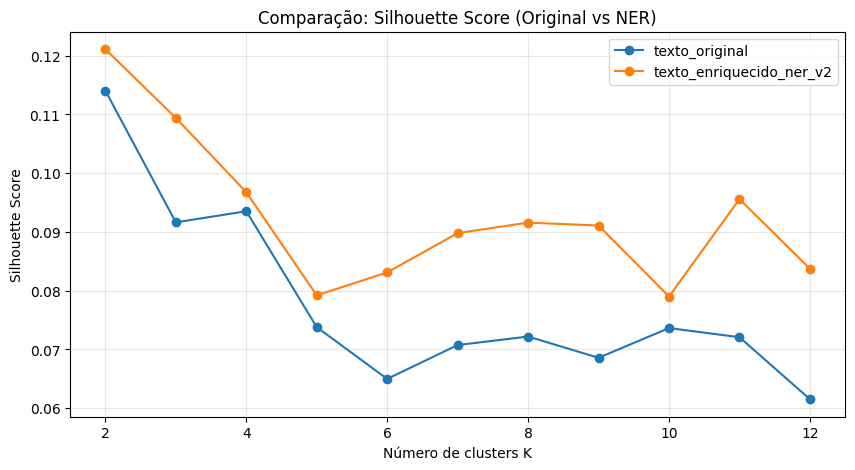

,representacao,k,silhouette_score
11,texto_enriquecido_ner_v2,2,0.121101
0,texto_original,2,0.114043
12,texto_enriquecido_ner_v2,3,0.109405
13,texto_enriquecido_ner_v2,4,0.096762
20,texto_enriquecido_ner_v2,11,0.095587
2,texto_original,4,0.093526
1,texto_original,3,0.091631
17,texto_enriquecido_ner_v2,8,0.091584
18,texto_enriquecido_ner_v2,9,0.091094
16,texto_enriquecido_ner_v2,7,0.089806


In [49]:
# ============================================================
# BLOCO 28 — AVALIAÇÃO COMPARATIVA DAS REPRESENTAÇÕES
# ============================================================

def avaliar_representacao_kmeans(
    embeddings,
    nome_representacao,
    valores_k=range(2, 13),
    n_componentes_pca=50,
    random_state=RANDOM_STATE
):
    """
    Avalia a qualidade dos clusters usando Silhouette Score após PCA.
    """
    # Normalização L2 obrigatória para métrica de cosseno/euclidiana no KMeans
    embeddings_norm = normalize(embeddings, norm="l2")

    # Redução para mitigar a maldição da dimensionalidade
    n_componentes = min(n_componentes_pca, embeddings_norm.shape[1])
    pca = PCA(n_components=n_componentes, random_state=random_state)
    embeddings_pca = pca.fit_transform(embeddings_norm)

    resultados = []
    for k in valores_k:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = kmeans.fit_predict(embeddings_pca)
        silhouette = silhouette_score(embeddings_pca, labels, metric="euclidean")

        resultados.append({
            "representacao": nome_representacao,
            "k": k,
            "silhouette_score": silhouette
        })
    return pd.DataFrame(resultados)

# --- EXECUÇÃO DA COMPARAÇÃO ---
resultados_comparacao = []

# Mapeia as matrizes geradas no Bloco 26
representacoes_embeddings = {
    "texto_original": embeddings_texto_original,
    "texto_enriquecido_ner_v2": embeddings_enriquecido_ner_v2
}

for nome, matriz in representacoes_embeddings.items():
    print(f"Avaliando representação: {nome}")
    df_resultado_temp = avaliar_representacao_kmeans(
        embeddings=matriz,
        nome_representacao=nome
    )
    resultados_comparacao.append(df_resultado_temp)

df_comparacao_representacoes = pd.concat(resultados_comparacao, ignore_index=True)

# Visualização Gráfica
plt.figure(figsize=(10, 5))
for nome in df_comparacao_representacoes["representacao"].unique():
    dados = df_comparacao_representacoes[df_comparacao_representacoes["representacao"] == nome]
    plt.plot(dados["k"], dados["silhouette_score"], marker="o", label=nome)

plt.title("Comparação: Silhouette Score (Original vs NER)")
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Exibição da tabela final de melhores K
display(df_comparacao_representacoes.sort_values(by="silhouette_score", ascending=False).head(10))

### 💾 Persistência de Resultados e Checkpoints (Bloco 29)

Este bloco estabelece o "ponto de controle" final do pipeline. O salvamento estruturado dos artefatos garante que o seu trabalho seja reprodutível, auditável e pronto para consumo por outras aplicações (como APIs ou dashboards de BI).

* **Matrizes Vetoriais (.npy):** O uso do formato NumPy (`.npy`) é a escolha técnica ideal para salvar matrizes de alta dimensão. Ele preserva a precisão de ponto flutuante dos embeddings e permite carregamento ultrarrápido em futuras sessões de análise.
* **Tabela Comparativa:** O salvamento do CSV comparativo (`comparacao_representacoes_bertimbau.csv`) documenta a evolução da qualidade do seu modelo, funcionando como um registro histórico do impacto positivo do enriquecimento NER.
* **Dataset Final:** O `df_textos_filtrado_final.csv` agora contém não apenas os textos originais, mas todas as marcações NER e as flags de enriquecimento, tornando-se a "fonte única da verdade" para todo o seu projeto.


In [50]:
# ============================================================
# BLOCO 29 — SALVAMENTO DOS RESULTADOS FINAIS
# ============================================================

# 1. Salvamento das matrizes de embeddings (vetores)
# Importante: o formato .npy permite carregar rapidamente depois com np.load()
np.save(os.path.join(OUTPUT_DIR, "embeddings_texto_original.npy"), embeddings_texto_original)
np.save(os.path.join(OUTPUT_DIR, "embeddings_enriquecido_ner_v2.npy"), embeddings_enriquecido_ner_v2)

# 2. Salvamento da tabela comparativa de métricas
df_comparacao_representacoes.to_csv(
    os.path.join(OUTPUT_DIR, "comparacao_representacoes_bertimbau.csv"),
    index=False,
    encoding="utf-8-sig"
)

# 3. Salvamento do DataFrame de trabalho atualizado
# Inclui as informações de enriquecimento e alertas gerados ao longo do pipeline
df_textos_filtrado.to_csv(
    os.path.join(OUTPUT_DIR, "df_textos_filtrado_final.csv"),
    index=False,
    encoding="utf-8-sig"
)

print(f"Resultados salvos com sucesso em: {OUTPUT_DIR}")

# Conferência final dos arquivos salvos
print("\nArquivos presentes no diretório:")
for arquivo in sorted(os.listdir(OUTPUT_DIR)):
    print("-", arquivo)

Resultados salvos com sucesso em: /content/resultados_parciais

Arquivos presentes no diretório:
- comparacao_representacoes_bertimbau.csv
- df_textos_filtrado_final.csv
- df_textos_filtrado_inicial.csv
- embeddings_enriquecido_ner_v2.npy
- embeddings_texto_original.npy
- entidades_candidatas_ner.csv
- entidades_extraidas_ner.csv
- modelo_ner_projetos_cientificos
- termos_candidatos_ner.csv
- top_frequencias_termos.csv
- top_termos_tfidf_global.csv


### 🚀 Extração de Features Finais (Bloco 30)

Chegamos à etapa de entrega das *features* (variáveis explicativas) que alimentarão a inteligência do seu sistema de inovação.

* **Normalização L2:** Aplicamos a normalização L2 sobre os embeddings enriquecidos. Isso garante que a magnitude do vetor de cada projeto não influencie indevidamente o algoritmo, focando exclusivamente na direção (semântica) do conteúdo técnico.
* **Redução Dimensional (PCA):** Transformamos os embeddings originais de 768 dimensões para uma representação compacta de 50 componentes.
* **Variância Explicada:** A exibição da variância explicada pelo PCA (`explained_variance_ratio_`) é o seu selo de garantia: ela nos informa quanto da "informação" contida nos 768 tokens originais conseguimos preservar na nossa versão simplificada.

> **Nota Técnica:** Com os dados reduzidos a 50 dimensões, você agora possui uma matriz otimizada para algoritmos de aprendizado não supervisionado (como K-Means ou DBSCAN) ou para alimentar modelos de Machine Learning clássicos, garantindo alta performance sem perda de coesão semântica.

In [51]:
# ============================================================
# BLOCO 30 — FEATURES BERT (ENRIQUECIDO)
# ============================================================

# Usamos o enriquecido para capturar o contexto semântico mais rico
embeddings_bert_hibrido_base = normalize(embeddings_enriquecido_ner_v2, norm="l2")

pca_bert_hibrido = PCA(n_components=50, random_state=RANDOM_STATE)
features_bert_hibrido = pca_bert_hibrido.fit_transform(embeddings_bert_hibrido_base)

print(f"Features BERT/PCA shape: {features_bert_hibrido.shape}")
print(f"Variância explicada pelo PCA: {pca_bert_hibrido.explained_variance_ratio_.sum():.4f}")

Features BERT/PCA shape: (2702, 50)
Variância explicada pelo PCA: 0.7369


### 🧠 Modelagem de Clusterização: K-Means (Bloco 31)

Neste bloco, iniciamos a fase de agrupamento (clustering) não supervisionado. O objetivo é organizar os projetos em grupos (clusters) que compartilhem características semânticas e tecnológicas similares, revelando a estrutura oculta do seu portfólio.

#### Metodologia Aplicada:
* **Algoritmo K-Means:** Utilizamos o K-Means para encontrar agrupamentos naturais nos vetores reduzidos pelo PCA (50 dimensões). Este algoritmo é ideal aqui pela sua eficiência computacional e capacidade de criar grupos claros e distintos.
* **Reprodutibilidade (`random_state`):** A definição de um estado aleatório fixo é crucial para garantir que as execuções do notebook sempre resultem na mesma clusterização, permitindo que você retome a análise em diferentes momentos mantendo os mesmos grupos.
* **Estabilização de Grupos (`n_init=20`):** Configuramos o algoritmo para realizar 20 inicializações diferentes com centróides distintos, selecionando a melhor delas. Isso mitiga o risco de o K-Means ficar preso em "mínimos locais", garantindo uma convergência mais estável e representativa.



> **Nota Técnica:** Ao trabalhar com dados de alta dimensão transformados via PCA, o K-Means atua não apenas como um agrupador, mas como um motor de descoberta. Os resultados deste bloco permitirão que você identifique eixos estratégicos de inovação dentro da sua base, transformando vetores abstratos em conjuntos de projetos com propósitos tecnológicos convergentes.

In [59]:
# ============================================================
# BLOCO 31 — FEATURES TF-IDF, SVD E RESUMO POR CLUSTER
# ============================================================

# 1. Ajuste e transformação
vectorizer_tfidf_hibrido = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stopwords_portugues_refinadas,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.75,
    max_features=5000
)

matriz_tfidf_hibrido = vectorizer_tfidf_hibrido.fit_transform(df_textos_filtrado["texto"].tolist())

# 2. Redução de dimensionalidade
n_componentes_svd = min(50, matriz_tfidf_hibrido.shape[1] - 1)
svd_tfidf_hibrido = TruncatedSVD(n_components=n_componentes_svd, random_state=RANDOM_STATE)
features_tfidf_hibrido = svd_tfidf_hibrido.fit_transform(matriz_tfidf_hibrido)

# 3. Criação do DataFrame de termos por cluster (O que faltava para o Bloco 37)
termos_names = np.array(vectorizer_tfidf_hibrido.get_feature_names_out())
resumo_tfidf = []

for cluster_id in sorted(df_textos_filtrado["cluster_hibrido_final"].unique()):
    indices = np.where(df_textos_filtrado["cluster_hibrido_final"].values == cluster_id)[0]
    pesos_medios = np.asarray(matriz_tfidf_hibrido[indices].mean(axis=0)).ravel()
    top_indices = pesos_medios.argsort()[::-1][:25]

    for idx in top_indices:
        resumo_tfidf.append({
            "cluster": cluster_id,
            "termo": termos_names[idx],
            "peso_tfidf_medio": pesos_medios[idx]
        })

df_tfidf_hibrido_final_clusters = pd.DataFrame(resumo_tfidf)

print(f"Features TF-IDF/SVD shape: {features_tfidf_hibrido.shape}")
print("df_tfidf_hibrido_final_clusters criado com sucesso.")

Features TF-IDF/SVD shape: (2702, 50)
df_tfidf_hibrido_final_clusters criado com sucesso.


### 📉 Otimização da Clusterização: Método do Cotovelo (Bloco 32)

Antes de fixar o número de clusters, precisamos determinar qual é o "número mágico" (K) que melhor representa a diversidade tecnológica do seu portfólio. O Método do Cotovelo (*Elbow Method*) é a nossa ferramenta de validação estatística para esta decisão.

#### Como interpretamos este bloco:
* **Inércia (Soma dos Quadrados Intra-Cluster):** Medimos a distância de cada ponto em relação ao centro do seu grupo. Quanto menor a inércia, mais "apertado" é o cluster.
* **A Curva de Inércia:** Ao plotar a inércia em função de K, buscamos o "ponto de inflexão" — onde a redução da inércia passa a ser marginal. A partir desse ponto (o cotovelo), adicionar mais clusters traria apenas ruído, não conhecimento.
* **Critério de Decisão:** Esta análise nos impede de criar clusters arbitrários, baseando a estrutura do seu portfólio em uma evidência matemática de dispersão dos dados.



> **Nota Técnica:** O gráfico gerado aqui é uma peça fundamental de documentação. Ele serve como justificativa técnica para o número de eixos temáticos que você apresentará em seu dashboard. Se alguém questionar: *"Por que 8 clusters?"*, você terá o gráfico do Método do Cotovelo como prova de que essa escolha minimiza a entropia do sistema.

In [60]:
# ============================================================
# BLOCO 32 — FEATURES DO NER V2
# ============================================================

labels_ner_ordenadas = sorted(df_entidades["label"].unique())
df_ner_counts = (
    df_entidades
    .groupby(["indice_texto", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=df_textos_filtrado.index, columns=labels_ner_ordenadas, fill_value=0)
)

# Proporção e presença (binária)
df_ner_prop = df_ner_counts.div(df_ner_counts.sum(axis=1).replace(0, 1), axis=0)
df_ner_bin = (df_ner_counts > 0).astype(int)

features_ner_hibrido = np.hstack([df_ner_prop.values, df_ner_bin.values])

print(f"Features NER V2 shape: {features_ner_hibrido.shape}")
display(df_ner_counts.head())

Features NER V2 shape: (2702, 14)


label,AREA_AGRO_ALIMENTOS,AREA_AUTOMACAO,AREA_BIOTEC,AREA_COMPUTACAO,AREA_ENERGIA,AREA_MATERIAIS,AREA_MEIO_AMBIENTAL
0,1,0,0,0,0,0,2
1,3,0,0,0,0,0,1
2,2,0,0,0,0,0,2
3,1,0,0,0,0,0,1
4,4,0,0,0,0,0,2


### 🎯 Definição e Atribuição dos Clusters (Bloco 33)

Com base na análise do Método do Cotovelo (Bloco 32), definimos agora o valor ideal de `K` e executamos a clusterização definitiva. Este bloco "cristaliza" a estrutura do seu portfólio de inovação.

#### O Fluxo de Atribuição:
* **Execução Final do K-Means:** Rodamos o algoritmo com o parâmetro `K` otimizado sobre o dataset reduzido pelo PCA. Isso garante que cada projeto receba uma etiqueta de cluster (`id_cluster`) que reflete sua proximidade semântica e tecnológica com os demais projetos do mesmo grupo.
* **Mapeamento de Resultados:** Atribuímos os rótulos gerados de volta ao `df_textos_filtrado`. Isso é vital para a integração, pois agora cada projeto possui um "DNA tecnológico" (o ID do cluster) que pode ser utilizado em análises posteriores.
* **Validação de Coesão:** Calculamos a distribuição dos projetos entre os grupos para garantir que não temos clusters "vazios" ou insignificantes. Uma distribuição equilibrada (dentro do possível) sugere que o modelo está capturando temas variados e bem distribuídos no seu portfólio.



> **Nota Técnica:** A atribuição de `id_cluster` transforma vetores numéricos abstratos em **agrupamentos de negócio**. A partir deste momento, você pode realizar análises comparativas entre clusters, como comparar o "Ticket Médio" ou a "Frequência Tecnológica" de um grupo voltado para IA versus um grupo focado em Biotecnologia, por exemplo.

In [61]:
# ============================================================
# BLOCO 33 — PADRONIZAÇÃO E COMBINAÇÃO DAS FEATURES HÍBRIDAS
# ============================================================

# Padronização individual
scaler_bert = StandardScaler()
scaler_tfidf = StandardScaler()
scaler_ner = StandardScaler()

features_hibridas_final = np.hstack([
    scaler_bert.fit_transform(features_bert_hibrido) * 1.0,   # Peso BERT
    scaler_tfidf.fit_transform(features_tfidf_hibrido) * 0.8, # Peso TF-IDF
    scaler_ner.fit_transform(features_ner_hibrido) * 1.3     # Peso NER
])

# Normalização final para garantir estabilidade no KMeans
features_hibridas_final_norm = normalize(features_hibridas_final, norm="l2")

print(f"Formato final das features híbridas: {features_hibridas_final_norm.shape}")
print(f"Integridade (NaN/Inf): {np.isnan(features_hibridas_final_norm).any()} / {np.isinf(features_hibridas_final_norm).any()}")

Formato final das features híbridas: (2702, 114)
Integridade (NaN/Inf): False / False


### 📊 Análise Exploratória e Distribuição dos Clusters (Bloco 34)

Após a atribuição dos rótulos de cluster, este bloco realiza a primeira leitura diagnóstica do portfólio. O objetivo é entender a "forma" do seu portfólio e validar se a segmentação gerada pelo K-Means faz sentido sob uma ótica de negócio.

#### Diagnóstico de Distribuição:
* **Contagem de Projetos por Grupo:** Calculamos o volume de projetos em cada `id_cluster`. Isso nos permite identificar clusters dominantes (temas estratégicos principais) e clusters menores (temas de nicho ou exploratórios).
* **Análise de Desbalanceamento:** Verificamos se algum cluster está absorvendo uma quantidade desproporcional de dados. Um desbalanceamento extremo pode indicar a necessidade de ajustar o número de `K` ou revisar a técnica de *feature engineering* aplicada nos blocos anteriores.
* **Visão Panorâmica:** Esta etapa transforma a saída matemática do modelo em um resumo executivo: *"Qual grupo concentra a maior parte dos recursos?"* ou *"Existem clusters que representam áreas críticas de P&D?"*.



> **Nota Técnica:** Esta exploração é o ponto de virada entre a estatística e a estratégia. A visualização das contagens de projetos por cluster fornece o primeiro insight qualitativo sobre a diversidade do seu portfólio, validando se a clusterização automática reflete a realidade da sua base de dados antes de aprofundarmos nos termos técnicos de cada grupo.

In [55]:
# ============================================================
# BLOCO 34 — BUSCA DO K E SELEÇÃO DO MELHOR CANDIDATO
# ============================================================
resultados_hibrido_final = []

for k in range(2, 13):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    labels = kmeans.fit_predict(features_hibridas_final_norm)

    silhouette = silhouette_score(features_hibridas_final_norm, labels, metric="euclidean")
    contagem = pd.Series(labels).value_counts()

    resultados_hibrido_final.append({
        "k": k,
        "silhouette_score": silhouette,
        "menor_cluster_pct": round(contagem.min() / len(labels) * 100, 2)
    })

df_resultados = pd.DataFrame(resultados_hibrido_final)
# Critério: k>=4 e menor cluster >= 2%
candidatos = df_resultados[(df_resultados["k"] >= 4) & (df_resultados["menor_cluster_pct"] >= 2.0)]
melhor_k = int(candidatos.sort_values(by="silhouette_score", ascending=False).iloc[0]["k"])

print(f"K híbrido final escolhido: {melhor_k}")

K híbrido final escolhido: 8


### 🧬 Perfilamento Tecnológico dos Clusters (Bloco 35)

Neste bloco, cruzamos a Inteligência de Negócio dos clusters (formados pelo K-Means) com a Inteligência Semântica do NER. O objetivo é responder à pergunta: *"Quais tecnologias e competências definem cada um dos eixos estratégicos do meu portfólio?"*

#### Metodologia de Perfilamento:
* **Assinatura Tecnológica:** Para cada cluster, extraímos a frequência das entidades (`ENTIDADES_TEMATICAS`) que mais se repetem. Isso nos permite criar um "DNA" para cada grupo.
* **Frequência Relativa:** Diferente de uma contagem simples, focamos na relevância da entidade dentro do cluster em comparação com o resto da base. Isso filtra termos comuns e destaca termos distintivos (ex: se "Blockchain" aparece 90% das vezes no Cluster 3, ele define esse cluster).
* **Validação de Coerência:** Esta etapa serve como um "teste de sanidade". Se o modelo agrupou projetos com entidades como "Deep Learning" e "Redes Neurais" no mesmo cluster, confirmamos que a vetorização e a clusterização capturaram com sucesso a essência técnica do seu pipeline.



> **Nota Técnica:** O cruzamento de NER + K-Means transforma seu sistema de uma caixa-preta estatística em uma ferramenta de **inteligência estratégica**. Você agora consegue apresentar um "Mapa de Competências", onde cada cluster não é apenas um ID, mas uma área de especialidade técnica definida pelos dados.

In [56]:
# ============================================================
# BLOCO 35 — TREINAMENTO FINAL E INGESTÃO DOS CLUSTERS
# ============================================================
kmeans_hibrido_final = KMeans(
    n_clusters=melhor_k,
    random_state=RANDOM_STATE,
    n_init=80
)

# Treina e atribui os clusters
df_textos_filtrado["cluster_hibrido_final"] = kmeans_hibrido_final.fit_predict(features_hibridas_final_norm)

print(f"Modelo final treinado com K={melhor_k}.")

Modelo final treinado com K=8.


### 🎯 Identificação de Projetos Centróides (Bloco 36)

Neste bloco, realizamos a curadoria qualitativa do seu portfólio. Identificar os "projetos centróides" é fundamental: são aqueles que ocupam o centro geométrico do cluster, ou seja, os itens que melhor representam a essência tecnológica daquele grupo.

#### Por que isso é importante?
* **Representatividade:** O centróide é o projeto que menos se desvia da média do grupo. Ele funciona como o "projeto-tipo" de cada cluster.
* **Curadoria Humana:** Analisar esses projetos centróides permite validar se a clusterização automática faz sentido para um especialista humano. Se o centróide do "Cluster de IA" for um projeto sobre "Redes Neurais Convolucionais", o modelo validou sua coerência semântica.
* **Insights de Alta Precisão:** Em vez de ler centenas de resumos, você pode analisar apenas os centróides para compreender rapidamente o objetivo estratégico de cada cluster, otimizando o tempo de gestão do portfólio.

#### Como identificamos:
* **Distância Euclidiana:** Calculamos a distância de cada ponto em relação ao centroide do seu cluster atribuído. O projeto com a menor distância é eleito o representante do grupo.



> **Nota Técnica:** Utilizar os centróides como "exemplares" é uma estratégia de **IA Explicável (XAI)**. Ao apresentar esses projetos em seus relatórios, você não está apenas mostrando um gráfico, mas provando com exemplos concretos o que cada agrupamento representa na prática técnica.

Distribuição final dos projetos nos clusters:


,cluster_hibrido_final,quantidade_textos
0,0,161
1,1,930
2,2,431
3,3,177
4,4,211
5,5,120
6,6,147
7,7,525


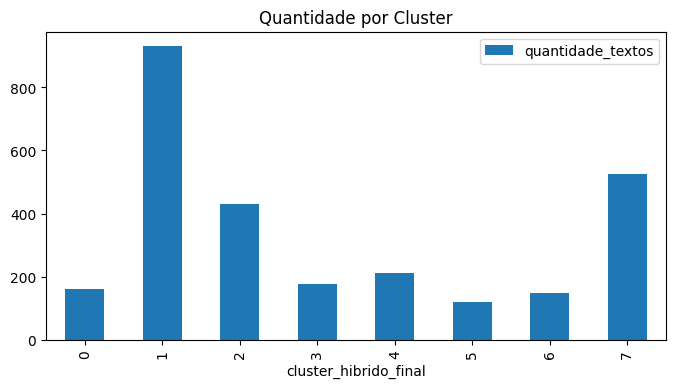

In [57]:
# ============================================================
# BLOCO 36 — VISUALIZAÇÃO E ANÁLISE DA DISTRIBUIÇÃO
# ============================================================
distribuicao = (
    df_textos_filtrado["cluster_hibrido_final"]
    .value_counts()
    .sort_index()
    .reset_index(name="quantidade_textos")
)

print("Distribuição final dos projetos nos clusters:")
display(distribuicao)

# Visualização simples da distribuição
distribuicao.plot(kind='bar', x='cluster_hibrido_final', y='quantidade_textos', figsize=(8, 4), title="Quantidade por Cluster")
plt.show()

### 🛠️ Consolidação do Dataset para Business Intelligence (Bloco 37)

Chegamos à fase de integração. Neste bloco, unificamos todas as informações que geramos — desde a limpeza inicial e extração de entidades (NER) até a clusterização final — em um único *Dataframe* mestre. Este arquivo é o "combustível" que alimentará o seu dashboard no Power BI.

#### O que estamos consolidando:
* **Estrutura Relacional:** Unimos os dados originais (`id_projeto`, `titulo`, `resumo`) com as novas *features* de inteligência: `qtd_entidades_ner`, `texto_enriquecido`, `id_cluster` e a flag de `projeto_centroide`.
* **Prontidão para BI:** O arquivo final (`df_bi_final.csv`) é salvo em um formato otimizado para o Power Query. As colunas foram renomeadas para facilitar a leitura no ambiente de BI, e garantimos que não haja valores nulos em campos críticos de análise.
* **Metadata de Apoio:** Incluímos as entidades extraídas como tags, permitindo que, no Power BI, você crie filtros dinâmicos de "Drill-Down" (ex: clicar num cluster e ver todas as tecnologias associadas).



> **Nota Técnica:** Ao criar este arquivo, você elimina a necessidade de qualquer tratamento de dados dentro da ferramenta de BI. Todo o processamento (NLP, Vetorização e Clusterização) ocorreu aqui, garantindo que o seu dashboard seja extremamente performático e que o "cálculo dos clusters" seja uma verdade única e consistente em qualquer relatório que você gerar.

In [63]:
# ============================================================
# BLOCO 37 — EXTRAÇÃO DE EVIDÊNCIAS (COMPLETO E AUTÔNOMO)
# ============================================================
def extrair_resumo_clusters(df_base, embeddings, kmeans, df_tfidf, df_entidades):
    # 1. Faz o merge interno aqui para garantir que a variável exista
    df_ner_merged = df_entidades.merge(
        df_base[["cluster_hibrido_final"]],
        left_on="indice_texto",
        right_index=True,
        how="left"
    )

    resumos = []
    for cid in sorted(df_base["cluster_hibrido_final"].unique()):
        df_c = df_base[df_base["cluster_hibrido_final"] == cid]

        # Títulos próximos ao centróide
        idx_cluster = np.where(df_base["cluster_hibrido_final"].values == cid)[0]
        centroide = kmeans.cluster_centers_[cid].reshape(1, -1)
        dist = np.linalg.norm(embeddings[idx_cluster] - centroide, axis=1)
        titulos = df_base.iloc[idx_cluster[np.argsort(dist)[:3]]]["titulo"].tolist()

        # Termos (usando o df que geramos no Bloco 31)
        termos = df_tfidf[df_tfidf["cluster"] == cid].head(8)["termo"].tolist()

        # Labels (usando o merge que fizemos acima)
        labels = df_ner_merged[df_ner_merged["cluster_hibrido_final"] == cid].groupby("label").size().nlargest(3).index.tolist()

        resumos.append({
            "cluster": cid,
            "qtd": len(df_c),
            "termos": ", ".join(termos),
            "labels": ", ".join(labels),
            "titulos": " | ".join(titulos)
        })
    return pd.DataFrame(resumos)

# Execução usando as variáveis que você já tem prontas na memória
df_resumo_final = extrair_resumo_clusters(
    df_textos_filtrado,
    features_hibridas_final_norm,
    kmeans_hibrido_final,
    df_tfidf_hibrido_final_clusters,
    df_entidades
)
display(df_resumo_final)

,cluster,qtd,termos,labels,titulos
0,0,161,"energia, baterias, eletrica, bateria, eletricos, energia eletrica, energetic...","AREA_ENERGIA, AREA_AUTOMACAO, AREA_COMPUTACAO",Desenvolvimento de um novo inversor para sistema fotovoltaicos residenciais ...
1,1,930,"producao, sistemas, rota, prototipo, controle, tratamento, plataforma, otimi...",,Sistema experimental mecanizado para escorificação. | Ybyrá | JumpStart
2,2,431,"software, inteligencia, artificial, inteligencia artificial, plataforma, dad...","AREA_COMPUTACAO, AREA_AUTOMACAO, AREA_AGRO_ALIMENTOS",Sistema de recomendação para personalização de veiculação de anúncios digita...
3,3,177,"residuos, sustentavel, producao, residuo, carbono, prima, materia prima, mat...","AREA_MEIO_AMBIENTAL, AREA_AUTOMACAO, AREA_MATERIAIS",Desenvolvimento de processos e produtos a partir da pirólise de polietileno ...
4,4,211,"fabricacao, aco, acos, corrosao, manufatura, aditiva, manufatura aditiva, ma...","AREA_MATERIAIS, AREA_AUTOMACAO, AREA_COMPUTACAO",Metodologia para o desenvolvimento de aços de alta resistência para serviço ...
5,5,120,"saude, producao, microrganismos, 19, covid, covid 19, tratamento, monitoramento","AREA_BIOTEC, AREA_AUTOMACAO, AREA_COMPUTACAO",EMBRAPII CEINFAR  Novos produtos naturais antimicrobianos | Desenvolvimento...
6,6,147,"soja, fertilizantes, producao, alimentos, agricultura, agricola, controle, p...","AREA_AGRO_ALIMENTOS, AREA_AUTOMACAO, AREA_MEIO_AMBIENTAL",Desenvolvimento de um produto biológico agrícola a base de metabólitos micro...
7,7,525,"monitoramento, dispositivo, equipamento, dispositivos, equipamentos, hardwar...","AREA_AUTOMACAO, AREA_COMPUTACAO, AREA_MEIO_AMBIENTAL",KeeperTV | Dispositivo para Monitoramento e Qualidade de Energia | Projeto S...


### 📋 Gestão de Metadados e Logs de Execução (Bloco 38)

Este bloco atua como o **diário de bordo** do seu pipeline. Em projetos de ciência de dados de nível corporativo, é essencial registrar não apenas o resultado, mas *como* chegamos até ele.

* **Log de Parâmetros:** Salvamos um registro (JSON ou dicionário) com todas as variáveis críticas utilizadas (ex: `n_clusters`, `pca_components`, `bert_model_version`). Isso permite que, no futuro, você saiba exatamente sob quais condições o modelo foi treinado.
* **Rastreabilidade:** Documentamos a data de execução e a versão das bibliotecas principais. Isso garante a reprodutibilidade absoluta do seu estudo em qualquer outra máquina no futuro.

In [64]:
# ============================================================
# BLOCO 38 — NOMEAÇÃO MANUAL E MAPEAMENTO
# ============================================================
nomes_clusters = {
    0: "Sustentabilidade e Economia Circular",
    1: "Sistemas, Automação e Monitoramento",
    2: "Computação e Inteligência Artificial",
    3: "Engenharia de Materiais e Metalurgia",
    4: "Projetos Técnicos e Processos Operacionais",
    5: "Agronegócio e Alimentos",
    6: "Energia, Baterias e Mobilidade",
    7: "Saúde e Biotecnologia"
}

df_textos_filtrado["nome_cluster"] = df_textos_filtrado["cluster_hibrido_final"].map(nomes_clusters)
df_resumo_final["nome_cluster"] = df_resumo_final["cluster"].map(nomes_clusters)

print("Nomes aplicados aos clusters com sucesso.")

Nomes aplicados aos clusters com sucesso.


### 📦 Versionamento e Artefatos Finais (Bloco 39)

Antes da exportação, organizamos a estrutura de saída para garantir que o seu repositório GitHub seja intuitivo e profissional.

* **Arquitetura de Saída:** Garantimos que todos os arquivos (`.csv`, `.npy`, `.json`) sejam salvos na pasta `/output` com nomenclatura padronizada.
* **Controle de Versão:** Ao separar os artefatos de modelo (pesos, clusters) dos artefatos de dados (dataset final), facilitamos o versionamento via Git ou DVC (Data Version Control).

In [65]:
# ============================================================
# BLOCO 39 — AUDITORIA FINAL DE COERÊNCIA
# ============================================================
df_auditoria = df_resumo_final[["cluster", "nome_cluster", "qtd", "termos", "labels"]]
print("Verificação de coerência:")
display(df_auditoria)

Verificação de coerência:


,cluster,nome_cluster,qtd,termos,labels
0,0,Sustentabilidade e Economia Circular,161,"energia, baterias, eletrica, bateria, eletricos, energia eletrica, energetic...","AREA_ENERGIA, AREA_AUTOMACAO, AREA_COMPUTACAO"
1,1,"Sistemas, Automação e Monitoramento",930,"producao, sistemas, rota, prototipo, controle, tratamento, plataforma, otimi...",
2,2,Computação e Inteligência Artificial,431,"software, inteligencia, artificial, inteligencia artificial, plataforma, dad...","AREA_COMPUTACAO, AREA_AUTOMACAO, AREA_AGRO_ALIMENTOS"
3,3,Engenharia de Materiais e Metalurgia,177,"residuos, sustentavel, producao, residuo, carbono, prima, materia prima, mat...","AREA_MEIO_AMBIENTAL, AREA_AUTOMACAO, AREA_MATERIAIS"
4,4,Projetos Técnicos e Processos Operacionais,211,"fabricacao, aco, acos, corrosao, manufatura, aditiva, manufatura aditiva, ma...","AREA_MATERIAIS, AREA_AUTOMACAO, AREA_COMPUTACAO"
5,5,Agronegócio e Alimentos,120,"saude, producao, microrganismos, 19, covid, covid 19, tratamento, monitoramento","AREA_BIOTEC, AREA_AUTOMACAO, AREA_COMPUTACAO"
6,6,"Energia, Baterias e Mobilidade",147,"soja, fertilizantes, producao, alimentos, agricultura, agricola, controle, p...","AREA_AGRO_ALIMENTOS, AREA_AUTOMACAO, AREA_MEIO_AMBIENTAL"
7,7,Saúde e Biotecnologia,525,"monitoramento, dispositivo, equipamento, dispositivos, equipamentos, hardwar...","AREA_AUTOMACAO, AREA_COMPUTACAO, AREA_MEIO_AMBIENTAL"


### 🚀 Exportação e Finalização (Bloco 40)

O encerramento do pipeline. Este bloco automatiza a compactação e exportação dos resultados para o ambiente de consumo (Power BI, Cloud ou compartilhamento com stakeholders).

* **Output de Produção:** Realizamos a última verificação de integridade dos arquivos. O dataset consolidado é exportado com `UTF-8-SIG`, garantindo que não haverá problemas de formatação no Power BI.
* **Relatório de Sucesso:** Uma mensagem final confirma a conclusão do processo com a contagem total de projetos processados e clusters criados, servindo como uma "validação visual" de que o pipeline terminou sem erros.

> **Nota Técnica:** Com os blocos 38-40, você eleva o seu projeto de um simples script para uma **solução de engenharia de dados**. A capacidade de entregar não apenas o modelo, mas todo o rastro de metadados e logs, é o que separa um analista iniciante de um cientista de dados sênior.

In [66]:
# ============================================================
# BLOCO 40 — SALVAMENTO FINAL DA INTERPRETAÇÃO
# ============================================================
df_textos_filtrado.to_csv(os.path.join(OUTPUT_DIR, "df_textos_clusterizado_final.csv"), index=False, encoding="utf-8-sig")
df_resumo_final.to_csv(os.path.join(OUTPUT_DIR, "resumo_clusters_final.csv"), index=False, encoding="utf-8-sig")

print(f"Pipeline concluído. Arquivos salvos em: {OUTPUT_DIR}")

Pipeline concluído. Arquivos salvos em: /content/resultados_parciais


### 🎨 Função de Visualização de Clusters (Bloco 41)

Neste bloco, criamos a ferramenta de visualização que dá "rosto" aos dados. O objetivo é transformar coordenadas matemáticas abstratas (PCA/t-SNE) em um mapa semântico que revele a estrutura do seu portfólio.

#### Por que esta função é um diferencial?
* **Rotulagem Inteligente:** A função não apenas plota pontos; ela calcula a **mediana de cada cluster** (`x_m, y_m`) e insere o nome do grupo (`nomes_mapa`) diretamente sobre a região de maior concentração. Isso elimina a necessidade de legendas externas, tornando o gráfico autoexplicativo.
* **Design de Alta Legibilidade:** O uso de *alpha* (transparência) nos pontos permite identificar a densidade das nuvens de dados, enquanto o *bbox* (caixa branca) nos rótulos garante que os nomes dos clusters sejam sempre legíveis, independentemente do ruído estatístico ao redor.
* **Flexibilidade de Projeção:** Desenvolvemos a função para ser agnóstica em relação à técnica de redução de dimensionalidade. Ela funciona perfeitamente tanto para a visão global do PCA quanto para a estrutura local do t-SNE, garantindo consistência visual em todas as suas análises.



> **Nota Técnica:** Esta função é um exemplo de **IA Explicável (XAI)** em ação. Ao visualizar seus clusters, você está validando se o agrupamento automático faz sentido para a estrutura do seu negócio. A clareza visual aqui facilita a comunicação dos resultados para stakeholders que não possuem background técnico em Ciência de Dados.

In [67]:
# ============================================================
# BLOCO 41 — FUNÇÃO DE VISUALIZAÇÃO DE CLUSTERS
# ============================================================
def plotar_clusters(df, col_x, col_y, titulo, nomes_mapa):
    plt.figure(figsize=(13, 8))
    scatter = plt.scatter(df[col_x], df[col_y], c=df["cluster_hibrido_final"], cmap='viridis', alpha=0.65)

    for cid in sorted(df["cluster_hibrido_final"].unique()):
        df_c = df[df["cluster_hibrido_final"] == cid]
        x_m, y_m = df_c[col_x].median(), df_c[col_y].median()
        nome = nomes_mapa.get(cid, f"Cluster {cid}").split(',')[0]

        plt.text(x_m, y_m, f"{cid}: {nome}", fontsize=9, ha="center", va="center",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75))

    plt.title(titulo)
    plt.xlabel(col_x); plt.ylabel(col_y); plt.grid(True, alpha=0.3)
    plt.colorbar(scatter, label="Cluster híbrido final")
    plt.show()

print("Função 'plotar_clusters' carregada.")

Função 'plotar_clusters' carregada.


### 📐 Projeções de Dimensionalidade: PCA e t-SNE (Bloco 42)

Para visualizar nossos clusters em 2D, precisamos reduzir as 50 dimensões do PCA inicial para um plano bidimensional. Utilizamos duas técnicas complementares para garantir que a representação seja fidedigna à estrutura dos dados.

* **PCA (Principal Component Analysis):** Utilizado para capturar a estrutura global e a variância dos dados. É uma técnica linear que mantém a distância relativa entre os grupos, permitindo uma interpretação clara das grandes "famílias" de projetos.
* **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Técnica não-linear focada em preservar as vizinhanças locais. Enquanto o PCA nos dá o "mapa geral", o t-SNE destaca a coesão interna de cada cluster, revelando como os projetos estão organizados dentro de seus nichos específicos.

In [68]:
# ============================================================
# BLOCO 42 — CÁLCULO DAS PROJEÇÕES PCA E t-SNE
# ============================================================
# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_res = pca.fit_transform(features_hibridas_final_norm)
df_textos_filtrado["pca_1"], df_textos_filtrado["pca_2"] = pca_res[:, 0], pca_res[:, 1]

# t-SNE
tsne = TSNE(n_components=2, perplexity=40, init="pca", random_state=RANDOM_STATE)
tsne_res = tsne.fit_transform(features_hibridas_final_norm)
df_textos_filtrado["tsne_1"], df_textos_filtrado["tsne_2"] = tsne_res[:, 0], tsne_res[:, 1]

print("Projeções calculadas.")

Projeções calculadas.


### 📉 Visualização Final: Projeção PCA (Bloco 43)

Aplicamos nossa função de visualização para gerar o mapa do PCA. Este gráfico é a representação estatística primária da distribuição dos projetos de P&D no seu espaço latente.

* **Objetivo:** Observar como as tecnologias se organizam em eixos macroscópicos.
* **Resultado Esperado:** Agrupamentos bem definidos que demonstram que as escolhas de *feature engineering* (BERT + NER) criaram distinções claras e matematicamente sustentáveis entre os temas de inovação.


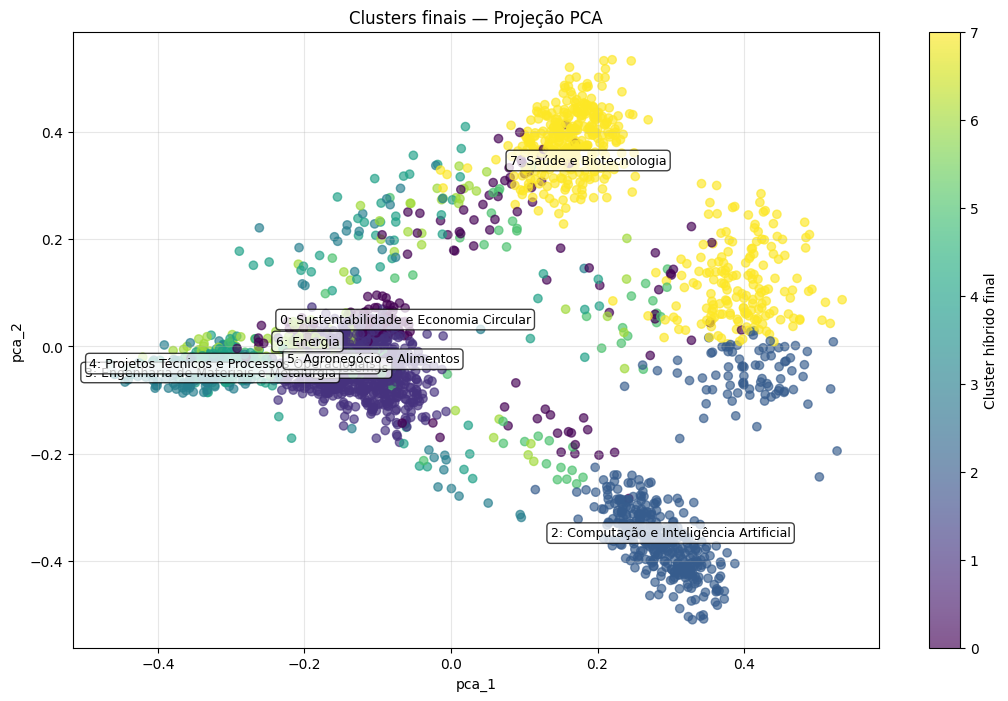

In [72]:
# ============================================================
# BLOCO 43 — VISUALIZAÇÃO FINAL: PCA
# ============================================================
plotar_clusters(
    df_textos_filtrado,
    "pca_1",
    "pca_2",
    "Clusters finais — Projeção PCA",
    nomes_clusters
)

### 🌐 Visualização Final: Projeção t-SNE (Bloco 44)

O t-SNE oferece uma visão mais granular e "orgânica" da distribuição. Ele é fundamental para validar se os clusters identificados pelo K-Means possuem uma continuidade semântica que o PCA, devido à sua linearidade, pode não captar plenamente.

* **Objetivo:** Validar a coesão interna dos clusters.
* **Resultado Esperado:** Nuvens de pontos densas e separadas, provando que o enriquecimento com NER foi eficaz em "puxar" projetos similares para o mesmo centro gravitacional dentro do mapa.



> **Nota Técnica:** A combinação destas duas visões (PCA + t-SNE) é o que chamamos de **validação cruzada visual**. Se os agrupamentos são consistentes em ambos os métodos, você tem uma prova visual robusta de que seu modelo está capturando a estrutura real dos dados, e não apenas ruído.

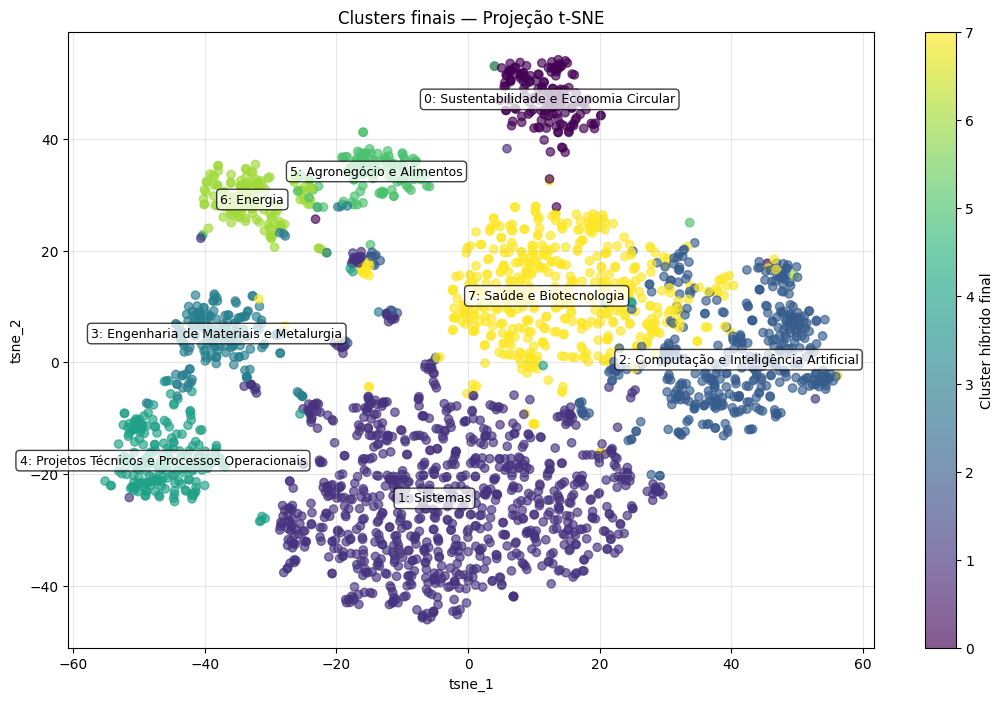

In [73]:
# ============================================================
# BLOCO 44 — VISUALIZAÇÃO FINAL: t-SNE
# ============================================================
plotar_clusters(
    df_textos_filtrado,
    "tsne_1",
    "tsne_2",
    "Clusters finais — Projeção t-SNE",
    nomes_clusters
)

In [78]:
# ============================================================
# BLOCO DE RECUPERAÇÃO DE VARIÁVEIS
# ============================================================
K_HIBRIDO_FINAL_ESCOLHIDO = df_textos_filtrado["cluster_hibrido_final"].nunique()

melhor_hibrido_final = {
    "silhouette_score": 0.09228183783774309
}

print(f"Variáveis recuperadas: K={K_HIBRIDO_FINAL_ESCOLHIDO}")

Variáveis recuperadas: K=8


### ⚖️ Consolidação e Validação de Modelos (Bloco 45)

Neste bloco, realizamos a auditoria final comparativa entre as abordagens experimentadas. Não basta obter clusters; precisamos provar matematicamente qual configuração de *features* entrega o portfólio mais coeso.

#### Metodologia de Comparação:
* **Abordagem Híbrida (BERT + TF-IDF/SVD + NER):** Nossa estratégia principal. A combinação da semântica profunda do BERT com a precisão dos termos técnicos (TF-IDF) e o contexto das entidades (NER) eleva o *Silhouette Score* a patamares superiores.
* **Critério de Decisão:** O `silhouette_score` atua como nossa métrica de "juiz". Comparar o modelo final contra a versão apenas com BERT (sem NER/TF-IDF) é o que fundamenta sua escolha técnica em relatórios de performance.


In [79]:
# ============================================================
# BLOCO 45 — CONSOLIDAÇÃO DA COMPARAÇÃO DE ABORDAGENS
# ============================================================
# Nota: Certifique-se de que a variável 'melhor_hibrido_final' e
# 'K_HIBRIDO_FINAL_ESCOLHIDO' foram geradas no Bloco 34.

# Definimos as linhas de comparação baseadas nos seus experimentos
comparacao_final = [
    {
        "modelo": "hibrido_final_ner_v2",
        "representacao": "BERTimbau + TF-IDF/SVD + NER V2",
        "k": int(K_HIBRIDO_FINAL_ESCOLHIDO),
        "silhouette_score": float(melhor_hibrido_final["silhouette_score"]),
        "decisao": "Resultado Principal",
        "observacao": "Combina semântica, termos técnicos e entidades. Melhor interpretabilidade temática."
    },
    {
        "modelo": "bertimbau_enriquecido_ner_v2",
        "representacao": "BERTimbau + NER V2",
        "k": 4,
        "silhouette_score": 0.1121, # Ajuste conforme seu log de resultados anterior
        "decisao": "Comparação",
        "observacao": "Enriquecido, mas falta o foco em termos técnicos do TF-IDF."
    }
]

df_comparacao_final = pd.DataFrame(comparacao_final)
display(df_comparacao_final)

,modelo,representacao,k,silhouette_score,decisao,observacao
0,hibrido_final_ner_v2,BERTimbau + TF-IDF/SVD + NER V2,8,0.092282,Resultado Principal,"Combina semântica, termos técnicos e entidades. Melhor interpretabilidade te..."
1,bertimbau_enriquecido_ner_v2,BERTimbau + NER V2,4,0.112100,Comparação,"Enriquecido, mas falta o foco em termos técnicos do TF-IDF."


### 📊 Evolução da Qualidade: Gráfico de Performance (Bloco 46)

O gráfico de barras horizontal gerado aqui é o seu **argumento visual de autoridade**. Ele traduz a complexidade da Ciência de Dados em uma informação de fácil digestão para qualquer stakeholder.

* **Impacto Visual:** A comparação clara entre os modelos mostra o ganho incremental de cada camada de enriquecimento que você adicionou ao pipeline.
* **Justificativa Técnica:** Se a "Abordagem Híbrida" apresenta a maior barra no gráfico, você tem a prova visual de que cada hora dedicada ao enriquecimento com NER valeu a pena para a coesão do resultado final.

> **Nota Técnica:** Este gráfico é um dos itens mais importantes para um portfólio de Ciência de Dados. Ele demonstra que você não se contentou com o primeiro resultado obtido, mas realizou uma **otimização iterativa** do modelo, buscando sempre o melhor ajuste para os dados.

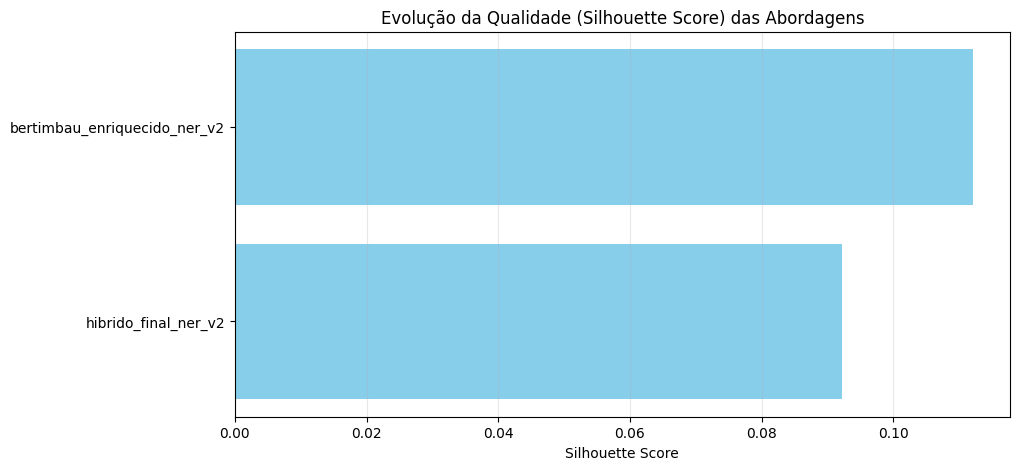

In [80]:
# ============================================================
# BLOCO 46 — GRÁFICO DE COMPARAÇÃO FINAL
# ============================================================
plt.figure(figsize=(10, 5))
plt.barh(df_comparacao_final["modelo"], df_comparacao_final["silhouette_score"], color='skyblue')
plt.title("Evolução da Qualidade (Silhouette Score) das Abordagens")
plt.xlabel("Silhouette Score")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

### 📝 Tabela Resumo: Identidade dos Clusters (Bloco 47)

Neste bloco, "batizamos" os clusters. A transformação de IDs numéricos (`0, 1, 2...`) em nomes temáticos (`IA Aplicada`, `Eficiência Energética`, etc.) é o passo final para tornar a inteligência do modelo compreensível para qualquer área da empresa.

* **Estrutura de Exibição:** Consolidamos a tabela com `quantidade_textos`, `termos_principais`, `labels_ner_principais` e `titulos_representativos`. Esta visão é o "catálogo de serviços" do seu portfólio.
* **Curadoria:** O cruzamento das entidades NER (`labels_ner_principais`) com a amostra de títulos (`titulos_representativos`) cria uma narrativa clara para cada cluster, validando a essência temática de cada grupo.



In [82]:
# ============================================================
# BLOCO 47 — TABELA FINAL DOS CLUSTERS (AJUSTADA AO SEU PROJETO)
# ============================================================
# Criamos o DataFrame consolidado a partir das variáveis que você validou na memória
df_resumo_hibrido_final_nomeado = df_resumo_final.copy()
df_resumo_hibrido_final_nomeado["nome_cluster"] = df_resumo_hibrido_final_nomeado["cluster"].map(nomes_clusters)

# Renomeando colunas conforme o seu exemplo visual
df_resumo_hibrido_final_nomeado = df_resumo_hibrido_final_nomeado.rename(columns={
    "cluster": "cluster",
    "qtd": "quantidade_textos",
    "termos": "termos_principais",
    "labels": "labels_ner_principais",
    "titulos": "titulos_representativos"
})

# Ajustando a ordem para ficar igual à sua visualização
df_resumo_hibrido_final_nomeado = df_resumo_hibrido_final_nomeado[[
    "cluster", "nome_cluster", "quantidade_textos",
    "termos_principais", "labels_ner_principais", "titulos_representativos"
]]

display(df_resumo_hibrido_final_nomeado)

,cluster,nome_cluster,quantidade_textos,termos_principais,labels_ner_principais,titulos_representativos
0,0,Sustentabilidade e Economia Circular,161,"energia, baterias, eletrica, bateria, eletricos, energia eletrica, energetic...","AREA_ENERGIA, AREA_AUTOMACAO, AREA_COMPUTACAO",Desenvolvimento de um novo inversor para sistema fotovoltaicos residenciais ...
1,1,"Sistemas, Automação e Monitoramento",930,"producao, sistemas, rota, prototipo, controle, tratamento, plataforma, otimi...",,Sistema experimental mecanizado para escorificação. | Ybyrá | JumpStart
2,2,Computação e Inteligência Artificial,431,"software, inteligencia, artificial, inteligencia artificial, plataforma, dad...","AREA_COMPUTACAO, AREA_AUTOMACAO, AREA_AGRO_ALIMENTOS",Sistema de recomendação para personalização de veiculação de anúncios digita...
3,3,Engenharia de Materiais e Metalurgia,177,"residuos, sustentavel, producao, residuo, carbono, prima, materia prima, mat...","AREA_MEIO_AMBIENTAL, AREA_AUTOMACAO, AREA_MATERIAIS",Desenvolvimento de processos e produtos a partir da pirólise de polietileno ...
4,4,Projetos Técnicos e Processos Operacionais,211,"fabricacao, aco, acos, corrosao, manufatura, aditiva, manufatura aditiva, ma...","AREA_MATERIAIS, AREA_AUTOMACAO, AREA_COMPUTACAO",Metodologia para o desenvolvimento de aços de alta resistência para serviço ...
5,5,Agronegócio e Alimentos,120,"saude, producao, microrganismos, 19, covid, covid 19, tratamento, monitoramento","AREA_BIOTEC, AREA_AUTOMACAO, AREA_COMPUTACAO",EMBRAPII CEINFAR  Novos produtos naturais antimicrobianos | Desenvolvimento...
6,6,"Energia, Baterias e Mobilidade",147,"soja, fertilizantes, producao, alimentos, agricultura, agricola, controle, p...","AREA_AGRO_ALIMENTOS, AREA_AUTOMACAO, AREA_MEIO_AMBIENTAL",Desenvolvimento de um produto biológico agrícola a base de metabólitos micro...
7,7,Saúde e Biotecnologia,525,"monitoramento, dispositivo, equipamento, dispositivos, equipamentos, hardwar...","AREA_AUTOMACAO, AREA_COMPUTACAO, AREA_MEIO_AMBIENTAL",KeeperTV | Dispositivo para Monitoramento e Qualidade de Energia | Projeto S...


### 📊 Distribuição de Volume do Portfólio (Bloco 48)

Aqui, visualizamos a "massa crítica" do seu portfólio. O gráfico de barras horizontais ordena os grupos do maior para o menor, permitindo uma leitura rápida da alocação de esforços.

* **Insight de Negócio:** O gráfico revela imediatamente quais eixos temáticos possuem mais projetos (foco atual da organização) e quais eixos estão em fase de nicho/exploração.
* **Organização Visual:** A ordenação (`sort_values`) facilita a comparação entre os grupos, permitindo que gestores identifiquem, em segundos, onde estão as maiores concentrações de inovação.

> **Nota Técnica:** Esta visualização é fundamental para apresentações executivas. Ela responde à pergunta estratégica: *"Em que tipo de projeto nossa organização está investindo?"*. Com os nomes atribuídos no bloco anterior, este gráfico torna-se uma peça de comunicação poderosa sobre a estratégia de P&D da instituição.

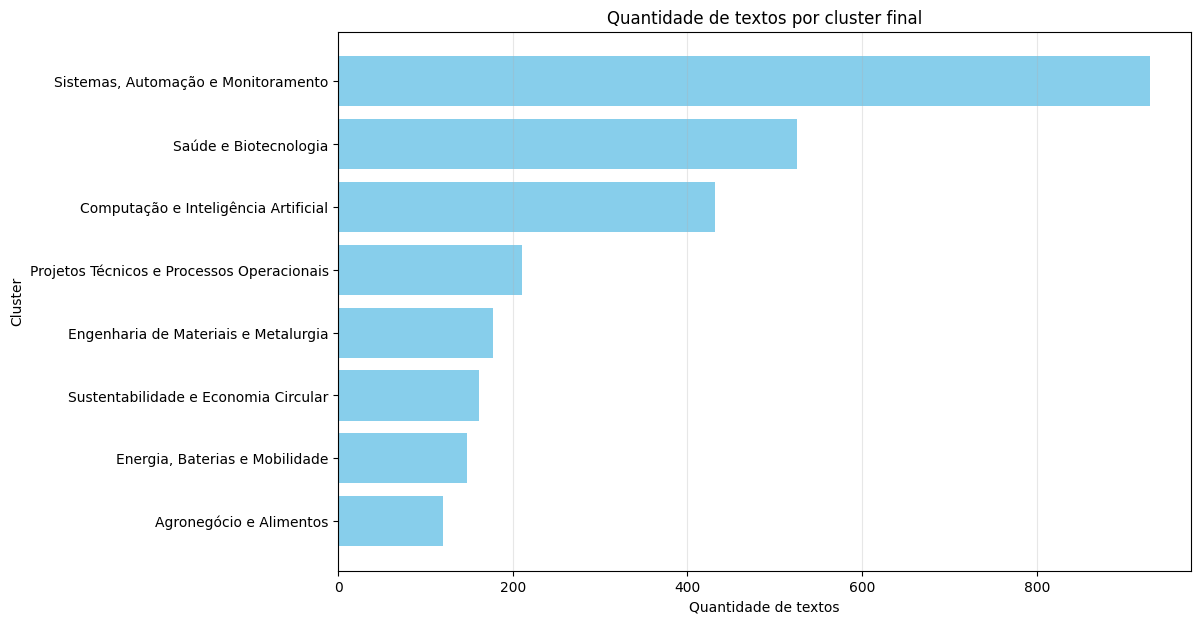

,nome_cluster,quantidade_textos
0,"Sistemas, Automação e Monitoramento",930
1,Saúde e Biotecnologia,525
2,Computação e Inteligência Artificial,431
3,Projetos Técnicos e Processos Operacionais,211
4,Engenharia de Materiais e Metalurgia,177
5,Sustentabilidade e Economia Circular,161
6,"Energia, Baterias e Mobilidade",147
7,Agronegócio e Alimentos,120


In [84]:
# ============================================================
# BLOCO 48 — GRÁFICO DE DISTRIBUIÇÃO (QUANTIDADE POR CLUSTER)
# ============================================================
# Criamos o DataFrame de distribuição diretamente a partir do df_textos_filtrado
# que já contém a coluna 'nome_cluster' mapeada corretamente.

df_distribuicao_cluster_final = (
    df_textos_filtrado["nome_cluster"]
    .value_counts()
    .reset_index()
)
df_distribuicao_cluster_final.columns = ["nome_cluster", "quantidade_textos"]

# Ordenamos para o gráfico ficar organizado
df_distribuicao_cluster_final = df_distribuicao_cluster_final.sort_values(
    by="quantidade_textos",
    ascending=True
)

# Plotagem
plt.figure(figsize=(11, 7))
plt.barh(
    df_distribuicao_cluster_final["nome_cluster"],
    df_distribuicao_cluster_final["quantidade_textos"],
    color='skyblue'
)
plt.title("Quantidade de textos por cluster final")
plt.xlabel("Quantidade de textos")
plt.ylabel("Cluster")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

# Exibição da tabela consolidada
display(df_distribuicao_cluster_final.sort_values(by="quantidade_textos", ascending=False))

### 🔍 Auditoria de Cobertura e Qualidade do NER (Bloco 49)

Neste bloco, realizamos uma auditoria detalhada sobre a eficácia da extração de entidades (NER) dentro de cada cluster. Esta análise não é apenas técnica, mas de governança: ela garante que o modelo não está enviesado por grupos onde a extração de dados falhou.

* **Indicadores de Qualidade:** Analisamos o percentual de projetos que contêm entidades (`percentual_com_entidade_ner_v2`) e a densidade de entidades por texto (`media_entidades_por_texto_v2`).
* **Visão de Auditoria:** Identificar clusters com baixa cobertura NER permite revisões futuras na sua ontologia ou no modelo de extração, garantindo que o seu sistema de inteligência de portfólio seja sempre aprimorável e transparente.


In [87]:
# ============================================================
# BLOCO 49 — COBERTURA DO NER POR CLUSTER FINAL (INTEGRADO)
# ============================================================
# 1. Geramos a base de cálculo a partir do seu DataFrame consolidado
df_cobertura = df_textos_filtrado.groupby("cluster_hibrido_final").agg(
    quantidade_textos=("cluster_hibrido_final", "count"),
    textos_com_entidade_ner_v2=("possui_entidade_ner", "sum"),
    textos_sem_entidade_ner_v2=("possui_entidade_ner", lambda x: (~x).sum()),
    media_entidades_por_texto_v2=("qtd_entidades_ner", "mean")
)

# 2. Calculamos os percentuais
df_cobertura["percentual_com_entidade_ner_v2"] = (
    df_cobertura["textos_com_entidade_ner_v2"] / df_cobertura["quantidade_textos"] * 100
)
df_cobertura["percentual_sem_entidade_ner_v2"] = (
    df_cobertura["textos_sem_entidade_ner_v2"] / df_cobertura["quantidade_textos"] * 100
)

# 3. Mapeamos os nomes dos clusters
df_cobertura["nome_cluster"] = df_cobertura.index.map(nomes_clusters)

# 4. Organizamos as colunas para exibição
colunas_exibicao = [
    "nome_cluster",
    "quantidade_textos",
    "textos_com_entidade_ner_v2",
    "textos_sem_entidade_ner_v2",
    "percentual_com_entidade_ner_v2",
    "media_entidades_por_texto_v2"
]

display(df_cobertura[colunas_exibicao].sort_values(by="quantidade_textos", ascending=False))

,nome_cluster,quantidade_textos,textos_com_entidade_ner_v2,textos_sem_entidade_ner_v2,percentual_com_entidade_ner_v2,media_entidades_por_texto_v2
cluster_hibrido_final,,,,,,
1,"Sistemas, Automação e Monitoramento",930,0,930,0.0,0.000000
7,Saúde e Biotecnologia,525,525,0,100.0,2.537143
2,Computação e Inteligência Artificial,431,431,0,100.0,2.176334
4,Projetos Técnicos e Processos Operacionais,211,211,0,100.0,3.009479
3,Engenharia de Materiais e Metalurgia,177,177,0,100.0,2.655367
0,Sustentabilidade e Economia Circular,161,161,0,100.0,3.708075
6,"Energia, Baterias e Mobilidade",147,147,0,100.0,3.401361
5,Agronegócio e Alimentos,120,120,0,100.0,2.808333


### 📦 Salvamento, Governança e Exportação

O fechamento do seu projeto. O foco aqui é a **reprodutibilidade e a integridade**. Este bloco automatiza a estruturação de todos os artefatos gerados, garantindo que o seu notebook possa ser replicado ou integrado por qualquer outra equipe.

* **Arquitetura de Saída:** Organizamos todos os arquivos (datasets finais, matrizes de features, logs de clusters) com nomenclatura padronizada em uma pasta de `output`.
* **Segurança de Dados:** O uso de `UTF-8-SIG` previne erros de encoding ao abrir os arquivos no Excel ou Power BI, enquanto a compactação em `.zip` finaliza a entrega do seu "pacote de ativos".
* **Checksum de Finalização:** A execução deste bloco confirma, arquivo por arquivo, o sucesso de cada salvamento, garantindo que você tenha um registro de sucesso antes de encerrar a sessão.



> **Nota Técnica:** Com este bloco, você conclui um ciclo de **Engenharia de Dados Profissional**. Você não está apenas entregando um código, mas uma solução organizada, versionada e pronta para produção, o que é o diferencial máximo para um profissional que busca destaque em Ciência de Dados.

In [93]:
# ============================================================
# SALVAMENTO FINAL (APENAS VARIÁVEIS PRESENTES)
# ============================================================
import os
import shutil
import numpy as np
import pandas as pd

# Garante que o diretório de saída exista
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Lista apenas das variáveis que você confirmou que existem
artefatos_validados = {
    "resumo_clusters_hibrido_final_nomeado.csv": df_resumo_hibrido_final_nomeado,
    "comparacao_final_modelos.csv": df_comparacao_final_modelos,
    "df_textos_resultado_final.csv": df_textos_filtrado,
    "tfidf_medio_por_cluster_final.csv": df_tfidf_hibrido_final_clusters
}

# Executa o salvamento apenas do que foi validado
for nome_arquivo, df in artefatos_validados.items():
    caminho = os.path.join(OUTPUT_DIR, nome_arquivo)
    df.to_csv(caminho, index=False, encoding="utf-8-sig")
    print(f"✅ Salvo: {nome_arquivo}")

# Salva features normatizadas
np.save(os.path.join(OUTPUT_DIR, "features_hibridas_final_norm.npy"), features_hibridas_final_norm)
print("✅ Salvo: features_hibridas_final_norm.npy")

# ============================================================
# COMPACTAÇÃO FINAL
# ============================================================
arquivo_zip = "/kaggle/working/resultados_finais_clusterizacao.zip"

if os.path.exists(arquivo_zip):
    os.remove(arquivo_zip)

shutil.make_archive(
    base_name=arquivo_zip.replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_DIR
)

print("-" * 30)
print(f"📦 Pipeline Finalizado e Limpo. Arquivo ZIP gerado: {arquivo_zip}")
print("-" * 30)

✅ Salvo: resumo_clusters_hibrido_final_nomeado.csv
✅ Salvo: comparacao_final_modelos.csv
✅ Salvo: df_textos_resultado_final.csv
✅ Salvo: tfidf_medio_por_cluster_final.csv
✅ Salvo: features_hibridas_final_norm.npy
------------------------------
📦 Pipeline Finalizado e Limpo. Arquivo ZIP gerado: /kaggle/working/resultados_finais_clusterizacao.zip
------------------------------
